# MEBL — End-to-End ML Pipeline for Next-Day Return Prediction

This notebook runs the full pipeline for **MEBL** on top of this project's production
feature dataset (`data/processed/MEBL_master.csv`, built by `build_features.py`):

1. Imports & setup
2. Data loading
3. Exploratory Data Analysis (price/volume history, returns, volatility, technical
   indicators, feature correlation with the target, macro context, target distribution)
4. Time-ordered train/test split (never a random/shuffled split for time series)
5. Model training - a deliberately wide variety, since the goal at this stage is
   experimentation, not picking a winner: Ridge, plain Linear Regression, SVR (linear
   kernel), SVR (RBF kernel), Random Forest, XGBoost, LightGBM, a feedforward neural
   network (MLP), and an LSTM sequence model (two deep learning models total)
6. Results comparison & visualization across all ~9 models (errors, directional accuracy,
   predicted vs. actual, residuals, feature importance, training/validation loss curves)
7. Overfitting/underfitting diagnostics - every model evaluated on both the data it was
   trained on and the held-out (unseen) test set, to tell a genuine predictive edge apart
   from memorized training noise
8. Concretely fixing what Section 7 finds - a real hyperparameter search (time-ordered
   validation split, never touching the test set) to regularize the overfitting tree
   ensembles and test whether the underfitting models were simply under-tuned
9. Cross-ticker comparison: MEBL vs. PSO

All modeling code reuses the project's own `feature_wrapper.py` / `model_factories.py` /
`walk_forward.py` so the numbers here are directly comparable to the production
walk-forward evaluation, not a separate one-off reimplementation.


## 1. Imports & Setup

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 80)

# Project root - this notebook lives in notebooks/, project modules live under src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'reports', 'notebooks_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TICKER = 'MEBL'
print('Project root:', PROJECT_ROOT)
print('Ticker:', TICKER)


Project root: E:\Python\Stock Predictor
Ticker: MEBL


In [2]:
# Project pipeline code - same functions the production training/evaluation use,
# so this notebook's results are directly comparable to the real walk-forward runs.
from src.psx_predictor.models.feature_wrapper import prepare_data, get_ticker_sectors, make_dead_zone_labels
from src.psx_predictor.models.model_factories import ridge_factory, baseline_factory, xgboost_factory, lightgbm_factory
from src.psx_predictor.models.walk_forward import directional_accuracy
from src.psx_predictor.models.ablation_study import (
    mean_absolute_error as mae_fn,
    mean_squared_error as mse_fn,
    mean_absolute_percentage_error as mape_fn,
)

# Extra libraries for this notebook's wider model sweep (SVM, plain linear
# regression, and two deep learning models) - not otherwise used by the
# production pipeline, so imported here rather than added to model_factories.py.
from sklearn.linear_model import LinearRegression, Ridge as RidgeClass
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

ticker_sectors = get_ticker_sectors()
print(f"Sector for {TICKER}: {ticker_sectors.get(TICKER)}")
print(f"Torch device: CPU (this dataset/model size trains in seconds on CPU - no GPU needed)")


2026-09-09 20:09:07,439 - src.psx_predictor.db.connection - INFO - Database engine and session factory created successfully.


Sector for MEBL: Commercial Banks
Torch device: CPU (this dataset/model size trains in seconds on CPU - no GPU needed)


## 2. Data Loading

In [3]:
master_path = os.path.join(PROCESSED_DIR, f"{TICKER}_master.csv")
df = pd.read_csv(master_path, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}  "
      f"({(df['date'].max() - df['date'].min()).days / 365.25:.1f} years)")
df.head()


Shape: 4853 rows x 276 columns
Date range: 2008-01-01 -> 2026-09-04  (18.7 years)


,ticker,date,open,high,low,close,volume,created_at,adjusted_close,sma_7,sma_7_dist,sma_21,sma_21_dist,sma_50,sma_50_dist,rsi_14,macd,macd_signal,macd_hist,daily_return,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,bollinger_mavg,bollinger_hband,bollinger_lband,bollinger_width,bb_middle_dist,bb_upper_dist,bb_lower_dist,vwap,vwap_14_dist,dow_sin,dow_cos,obv,relative_volume,return_vol_10,return_vol_20,...,williams_r,cci_14,parkinson_volatility_20d,garman_klass_volatility_20d,return_skewness_20d,return_kurtosis_20d,advance_decline_line,chaikin_money_flow_20d,day_of_week,month,quarter,is_year_end_season,pe_1y_avg,pe_3y_avg,pe_5y_avg,pb_percentile_3y,dividend_yield_percentile_3y,fear_index_proxy,greed_index_proxy,short_term_speculation_proxy,daily_traded_value,adv_20d,return_5d,return_20d,historical_volatility_20d,adx,plus_di,minus_di,sector_volatility_20d,oil_volatility_20d,bond_volatility_20d,cpi_expected,cpi_surprise,policy_rate_expected,eps_expected,eps_consensus_surprise,eps_qoq_surprise,history_days,history_maturity_ratio,pucars_sentiment_daily
0,MEBL,2008-01-01,4.273649,4.273649,4.062742,4.218148,300814,2026-08-11 13:03:54.093524+00:00,4.218148,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.951057,0.309017,0.0,0.0,0.0,0.0,...,-50.000000,0.0,0.00000,0.000000,0.0,0.0,0.316456,0.000000,1,1,1,0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000033,1.268878e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34.0,0.0,0.0,1,0.000206,0.0
1,MEBL,2008-01-02,4.218148,4.229249,4.051643,4.201498,1426858,2026-08-11 13:03:54.093531+00:00,4.201498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.001328,-0.000266,-0.001063,-0.003947,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.587785,-0.809017,0.0,0.0,0.0,0.0,...,-50.000000,0.0,0.00000,0.000000,0.0,0.0,-0.110374,0.000000,2,1,1,0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000134,5.994940e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34.0,0.0,0.0,2,0.000412,0.0
2,MEBL,2008-01-03,4.218149,4.406855,4.218149,4.406855,1306210,2026-08-11 13:03:54.093532+00:00,4.406855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014028,0.002593,0.011435,0.048877,-0.003947,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.587785,-0.809017,0.0,0.0,0.0,0.0,...,-50.000000,0.0,0.00000,0.000000,0.0,0.0,0.806293,0.000000,3,1,1,0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000124,5.756278e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34.0,0.0,0.0,3,0.000618,0.0
3,MEBL,2008-01-04,4.406854,4.490108,4.340252,4.362453,382854,2026-08-11 13:03:54.093533+00:00,4.362453,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022357,0.006546,0.015811,-0.010076,0.048877,-0.003947,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.951057,0.309017,0.0,0.0,0.0,0.0,...,-50.000000,0.0,0.00000,0.000000,0.0,0.0,1.253352,0.000000,4,1,1,0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000029,1.670183e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34.0,0.0,0.0,4,0.000824,0.0
4,MEBL,2008-01-07,4.273650,4.329152,4.273650,4.329152,279902,2026-08-11 13:03:54.093534+00:00,4.329152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025972,0.010431,0.015541,-0.007634,-0.010076,0.048877,-0.003947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0,...,-36.708859,0.0,0.02347,0.024092,0.0,0.0,1.241587,0.660099,0,1,1,0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.000008,1.211738e+06,739327.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,34.0,0.0,0.0,5,0.001030,0.0


In [4]:
df.info(memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Columns: 276 entries, ticker to pucars_sentiment_daily
dtypes: datetime64[us](1), float64(259), int64(13), str(3)
memory usage: 11.0 MB


## 3. Data Quality Overview

A quick check that the cleaned/engineered dataset is actually clean before we model it.

10 of 276 columns have any missing values.


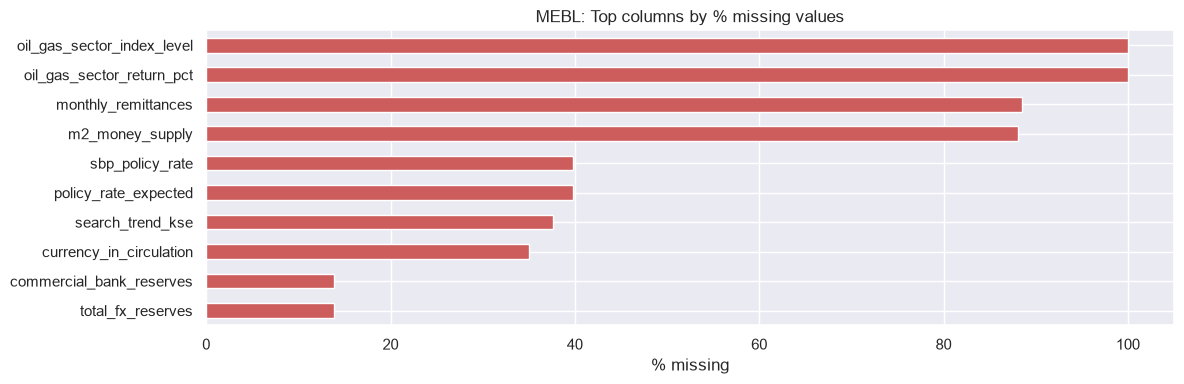

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"{len(missing_pct)} of {df.shape[1]} columns have any missing values.")
if len(missing_pct) > 0:
    fig, ax = plt.subplots(figsize=(12, max(4, min(0.3 * len(missing_pct), 10))))
    missing_pct.head(30).plot(kind='barh', ax=ax, color='indianred')
    ax.set_xlabel('% missing')
    ax.set_title(f'{TICKER}: Top columns by % missing values')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [6]:
df[['open', 'high', 'low', 'close', 'volume']].describe()


,open,high,low,close,volume
count,4853.000000,4853.000000,4853.000000,4853.000000,4.853000e+03
mean,65.037501,65.904139,64.239215,65.044052,7.045075e+05
std,113.905439,115.414412,112.519098,113.913322,1.255420e+06
min,0.457530,0.457530,0.457530,0.457530,0.000000e+00
25%,5.760992,5.821198,5.709092,5.787980,2.862300e+04
50%,20.206279,20.499130,20.182707,20.349218,2.509890e+05
75%,66.903740,67.581539,66.110566,66.721352,8.855550e+05
max,591.333554,596.758608,587.280029,591.442017,1.851994e+07


## 4. Price & Volume History

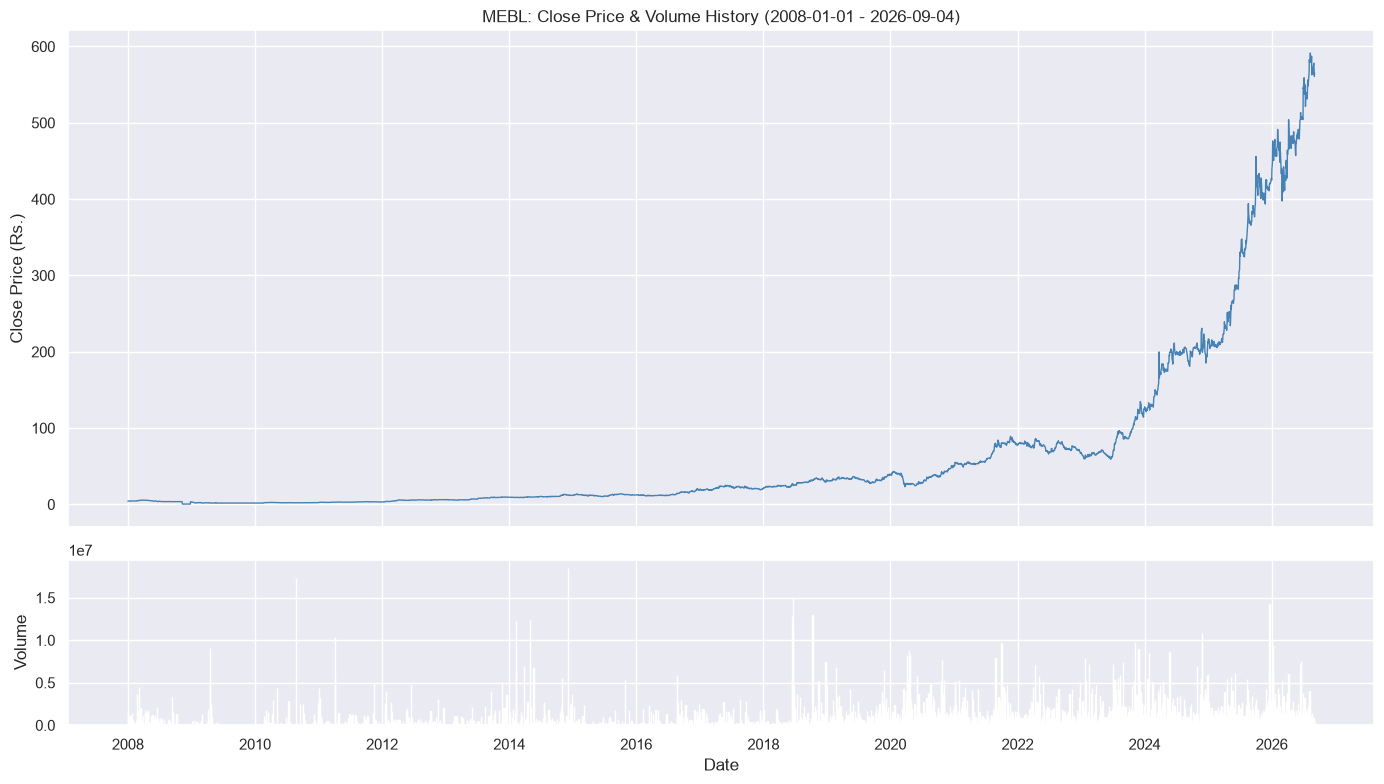

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df['date'], df['close'], color='steelblue', linewidth=1)
ax1.set_ylabel('Close Price (Rs.)')
ax1.set_title(f'{TICKER}: Close Price & Volume History ({df["date"].min().date()} - {df["date"].max().date()})')

ax2.bar(df['date'], df['volume'], color='slategray', width=1.5)
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


## 5. Returns & Volatility

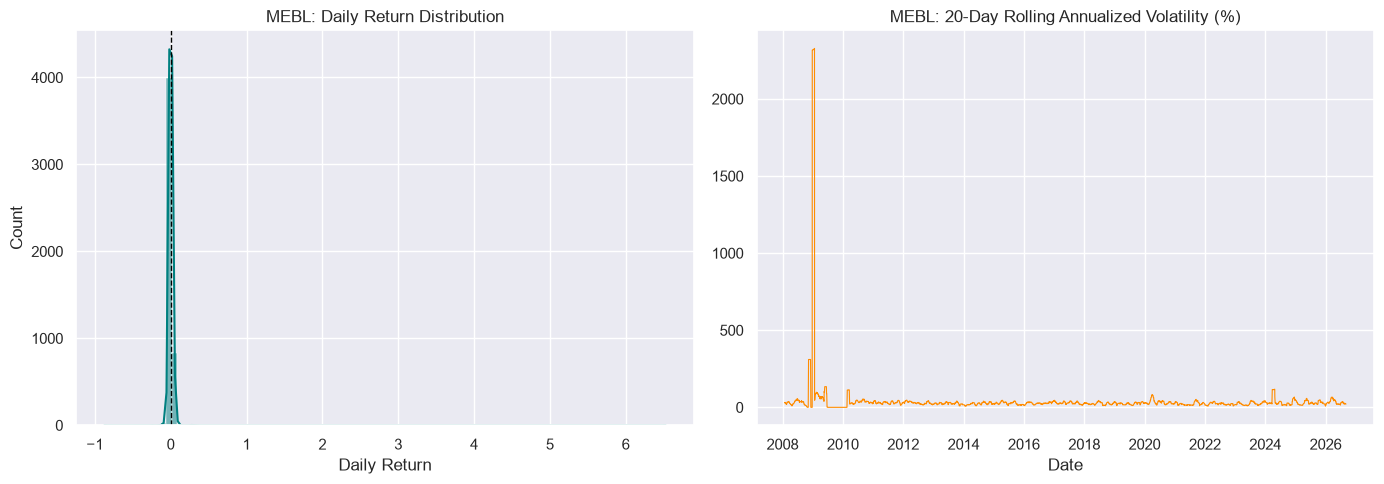

Mean daily return:  0.2391%
Std daily return:   9.6680%
Skewness:           63.188
Excess kurtosis:    4274.554  (fat tails vs. normal if > 0)


In [8]:
daily_return = df['close'].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(daily_return, bins=100, kde=True, ax=axes[0], color='teal')
axes[0].set_title(f'{TICKER}: Daily Return Distribution')
axes[0].set_xlabel('Daily Return')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

rolling_vol = daily_return.rolling(20).std() * np.sqrt(252) * 100  # annualized %
axes[1].plot(df['date'].iloc[1:], rolling_vol, color='darkorange', linewidth=0.8)
axes[1].set_title(f'{TICKER}: 20-Day Rolling Annualized Volatility (%)')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print(f"Mean daily return:  {daily_return.mean()*100:.4f}%")
print(f"Std daily return:   {daily_return.std()*100:.4f}%")
print(f"Skewness:           {daily_return.skew():.3f}")
print(f"Excess kurtosis:    {daily_return.kurtosis():.3f}  (fat tails vs. normal if > 0)")


## 6. Technical Indicators

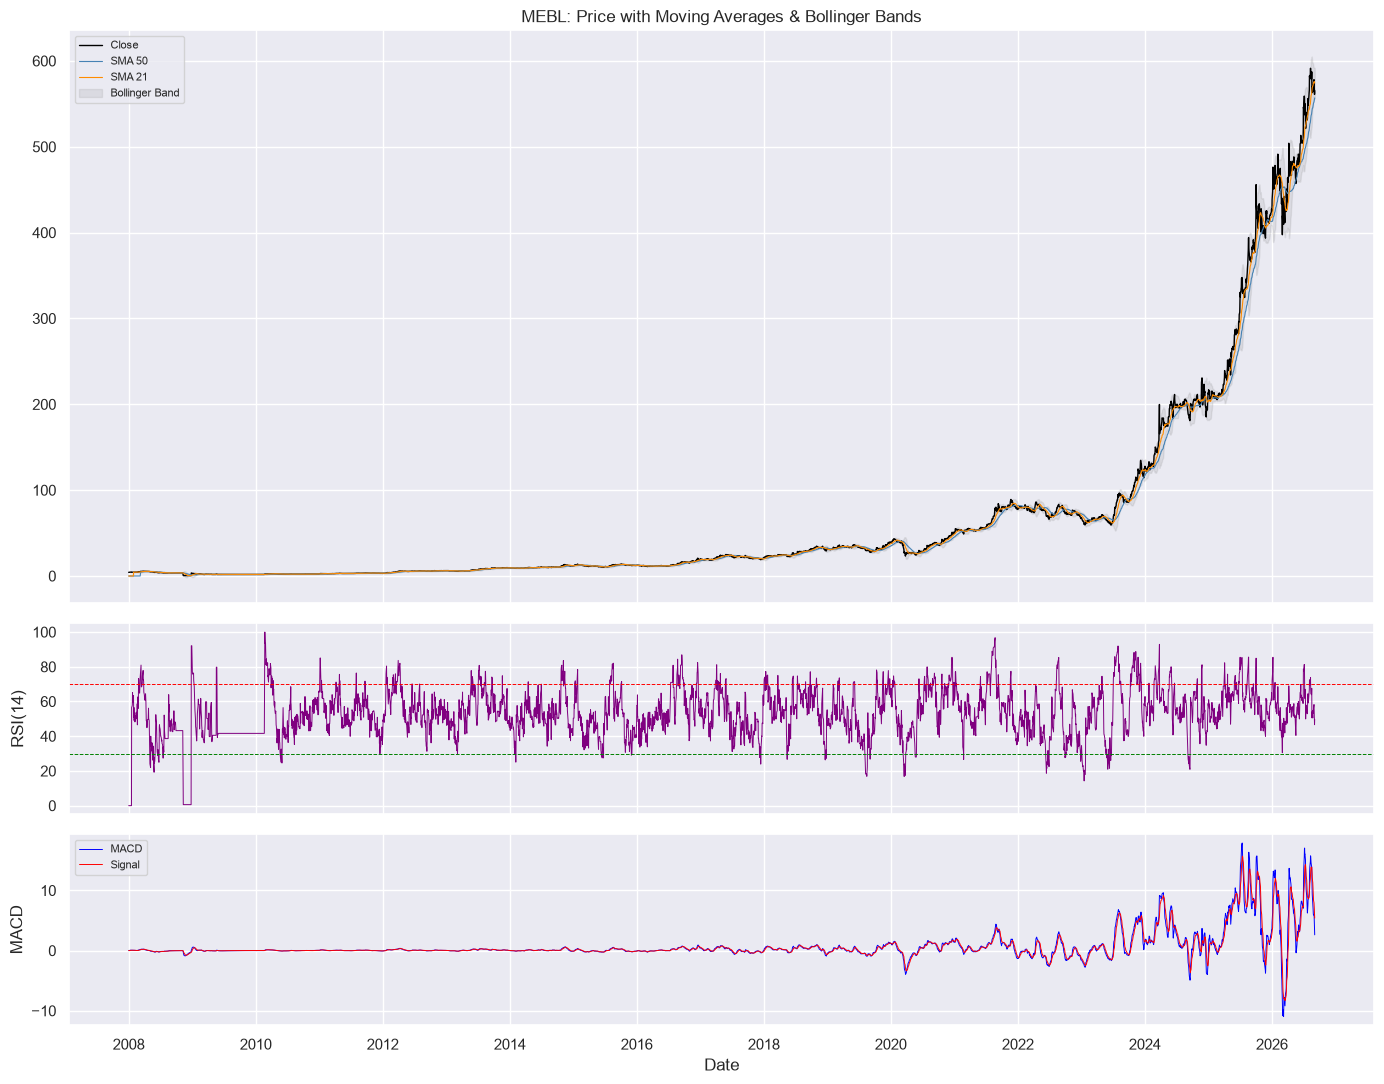

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})

# Price with SMAs and Bollinger Bands
axes[0].plot(df['date'], df['close'], label='Close', color='black', linewidth=1)
if 'sma_50' in df.columns:
    axes[0].plot(df['date'], df['sma_50'], label='SMA 50', color='steelblue', linewidth=0.8)
if 'sma_21' in df.columns:
    axes[0].plot(df['date'], df['sma_21'], label='SMA 21', color='darkorange', linewidth=0.8)
if {'bollinger_lband', 'bollinger_hband'}.issubset(df.columns):
    axes[0].fill_between(df['date'], df['bollinger_lband'], df['bollinger_hband'],
                          color='gray', alpha=0.15, label='Bollinger Band')
axes[0].set_title(f'{TICKER}: Price with Moving Averages & Bollinger Bands')
axes[0].legend(loc='upper left', fontsize=8)

# RSI
if 'rsi_14' in df.columns:
    axes[1].plot(df['date'], df['rsi_14'], color='purple', linewidth=0.7)
    axes[1].axhline(70, color='red', linestyle='--', linewidth=0.7)
    axes[1].axhline(30, color='green', linestyle='--', linewidth=0.7)
    axes[1].set_ylabel('RSI(14)')

# MACD
if {'macd', 'macd_signal'}.issubset(df.columns):
    axes[2].plot(df['date'], df['macd'], label='MACD', color='blue', linewidth=0.7)
    axes[2].plot(df['date'], df['macd_signal'], label='Signal', color='red', linewidth=0.7)
    axes[2].legend(loc='upper left', fontsize=8)
    axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()


## 7. Target Variable & Feature Correlation

The modeling target is next-day return, built the same way `feature_wrapper.prepare_data()` builds it for training: `(close[t+1] - close[t]) / close[t]`.

Feature matrix: 4852 rows x 273 columns
Target: target_return_t1


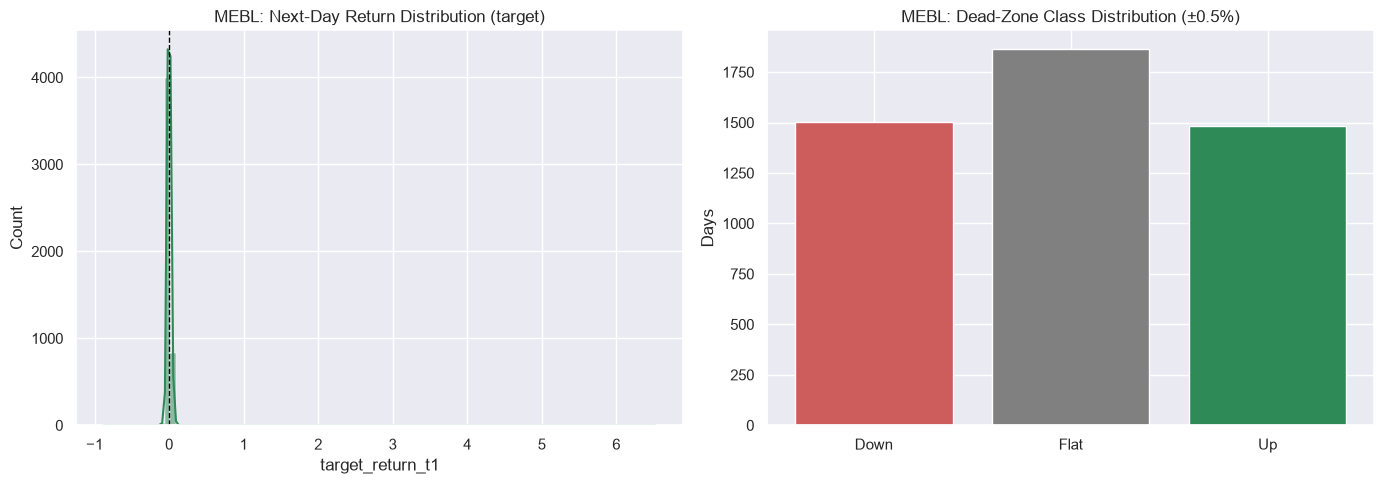

-1    1504
 0    1863
 1    1485
Name: count, dtype: int64


In [10]:
X_full, y_full, dates_full, close_full = prepare_data(TICKER, ticker_sectors)
print(f"Feature matrix: {X_full.shape[0]} rows x {X_full.shape[1]} columns")
print(f"Target: {y_full.name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(y_full, bins=100, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title(f'{TICKER}: Next-Day Return Distribution (target)')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

dead_zone = 0.005
target_class = make_dead_zone_labels(y_full, dead_zone=dead_zone)
class_counts = target_class.value_counts().sort_index()
class_labels = {-1: 'Down', 0: 'Flat', 1: 'Up'}
axes[1].bar([class_labels[i] for i in class_counts.index], class_counts.values,
            color=['indianred', 'gray', 'seagreen'])
axes[1].set_title(f'{TICKER}: Dead-Zone Class Distribution (±{dead_zone*100:.1f}%)')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()
print(class_counts)


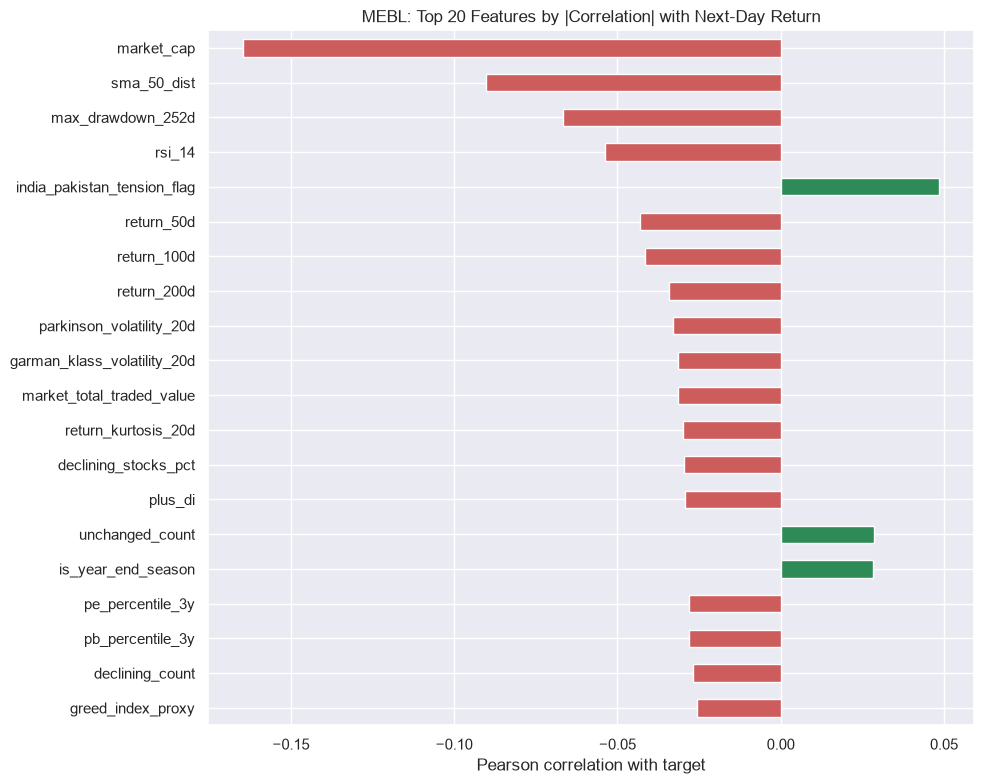

Note: correlations this close to zero across the board are expected for a next-day return target - this is close to a random walk, which is exactly why single-feature linear correlation is a weak lens and tree ensembles (which can pick up interactions) are used for the actual modeling below.


In [11]:
numeric_X = X_full.select_dtypes(include=['number'])
target_corr = numeric_X.corrwith(y_full).dropna().sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_corr = target_corr.head(20)
colors = ['seagreen' if v > 0 else 'indianred' for v in top_corr.values]
top_corr.iloc[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title(f'{TICKER}: Top 20 Features by |Correlation| with Next-Day Return')
ax.set_xlabel('Pearson correlation with target')
plt.tight_layout()
plt.show()

print("Note: correlations this close to zero across the board are expected for a "
      "next-day return target - this is close to a random walk, which is exactly why "
      "single-feature linear correlation is a weak lens and tree ensembles (which can "
      "pick up interactions) are used for the actual modeling below.")


## 8. Macro Context Sanity Check

A quick visual confirmation that the macro/rate series merged into this ticker's dataset move independently of price (as expected for a macro input, not a derived one).

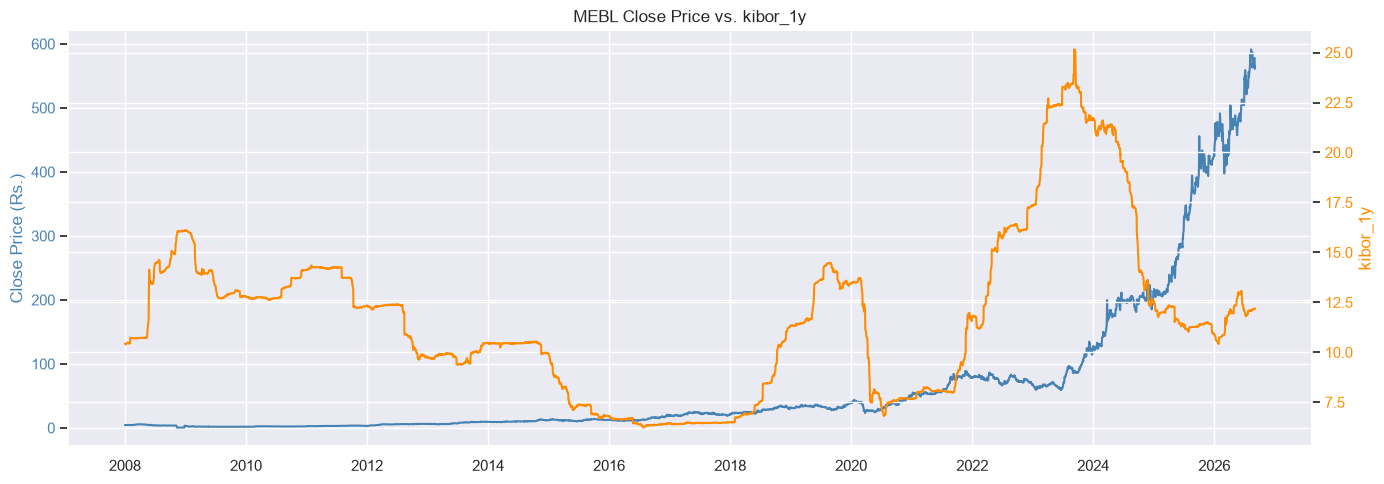

In [12]:
macro_col = 'kibor_1y' if 'kibor_1y' in df.columns else ('sbp_policy_rate' if 'sbp_policy_rate' in df.columns else None)

if macro_col:
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(df['date'], df['close'], color='steelblue', label='Close (Rs.)')
    ax1.set_ylabel('Close Price (Rs.)', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2 = ax1.twinx()
    ax2.plot(df['date'], df[macro_col], color='darkorange', label=macro_col)
    ax2.set_ylabel(macro_col, color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title(f'{TICKER} Close Price vs. {macro_col}')
    fig.tight_layout()
    plt.show()
else:
    print("No KIBOR/policy rate column found - skipping.")


## 9. Time-Ordered Train/Test Split

Financial time series must **never** use a random/shuffled train/test split - that leaks
future information into training. We use a fixed calendar cutoff so the test set is
strictly the most recent ~20% of trading history, matching how the production
`choose_global_cutoff()` / walk-forward evaluation splits data.

In [13]:
cutoff_idx = int(len(dates_full) * 0.8)
cutoff_date = dates_full.iloc[cutoff_idx]

train_mask = dates_full < cutoff_date
test_mask = ~train_mask

X_train, X_test = X_full[train_mask].copy(), X_full[test_mask].copy()
y_train, y_test = y_full[train_mask].copy(), y_full[test_mask].copy()
dates_train, dates_test = dates_full[train_mask], dates_full[test_mask]
close_train, close_test = close_full[train_mask], close_full[test_mask]

# XGBoost/LightGBM consume ticker & sector as native pandas categoricals
for col in ['ticker', 'sector']:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = pd.Categorical(X_test[col], categories=X_train[col].cat.categories)

print(f"Train: {len(X_train)} rows  ({dates_train.min().date()} -> {dates_train.max().date()})")
print(f"Test:  {len(X_test)} rows  ({dates_test.min().date()} -> {dates_test.max().date()})")
print(f"Split cutoff date: {cutoff_date.date()}")


Train: 3881 rows  (2008-01-01 -> 2022-11-17)
Test:  971 rows  (2022-11-18 -> 2026-09-03)
Split cutoff date: 2022-11-18


## 10. Model Training — Wide Model Sweep

This stage is deliberately exploratory - a wide variety of models, not a search for a
single winner:

| Family | Models |
|---|---|
| Linear | Ridge, plain Linear Regression |
| Kernel (SVM) | SVR (linear kernel), SVR (RBF kernel) |
| Tree ensembles | Random Forest, XGBoost, LightGBM |
| Deep learning | Feedforward Neural Network (MLP) - trained here; LSTM - Section 11 |

For each model we report both price-level error (MAE/RMSE/MAPE, reconstructed from the
predicted *return* applied to the last known close) and directional accuracy, each
against the correct naive baselines (zero-return persistence for price error;
"tomorrow repeats today's direction" for directional accuracy) - this mirrors
`walk_forward.py`'s corrected evaluation methodology exactly.

**Note on scaling:** Ridge, Linear Regression, both SVR kernels, and the MLP are all
scale-sensitive - fed this dataset's 270+ raw-scale columns (index levels in the
thousands next to percentage/ratio columns near zero) without standardization, a linear
model's coefficients blow up and its errors become meaningless (an unscaled Ridge run
produced MAE in the hundreds of thousands). Tree ensembles don't need this since they
split on thresholds, not distances/dot-products.

Standardizing alone was still not enough for the linear/kernel models: a handful of this
dataset's columns have a near-zero standard deviation across *training* history but a
genuine large value somewhere in the *test* window (e.g. a fundamentals figure that jumps
scale once in 18 years) - that single column's z-score can reach into the billions and
dominate a linear fit even after scaling. We clip standardized values to ±10 standard
deviations (a standard robust-scaling safeguard) for every scale-sensitive model - this is
a scaling-robustness fix, not a change to what's being measured.

In [14]:
class TorchMLPRegressor:
    """Minimal sklearn-compatible wrapper around a small PyTorch feedforward network
    (Linear -> ReLU -> Dropout, x2, -> Linear(1)) so it plugs into the same fit/predict
    loop as the sklearn models above. This is the first of this notebook's two deep
    learning models - a flat/non-sequential network on the same feature vector every
    other model sees. The second (Section 11, LSTM) instead sees a sliding window of
    recent days, which needs its own separate treatment."""

    def __init__(self, hidden_dims=(128, 64), epochs=60, lr=1e-3, patience=8,
                 batch_size=64, dropout=0.2, seed=42):
        self.hidden_dims = hidden_dims
        self.epochs = epochs
        self.lr = lr
        self.patience = patience
        self.batch_size = batch_size
        self.dropout = dropout
        self.seed = seed
        self.loss_history_ = {'train': [], 'val': []}

    def _build(self, input_dim):
        torch.manual_seed(self.seed)
        layers, prev = [], input_dim
        for h in self.hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(self.dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        return nn.Sequential(*layers)

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32).reshape(-1, 1)
        # Carve off the last 15% of (already time-ordered) training rows as a
        # validation slice for early stopping - never shuffle for a time series.
        val_cut = int(len(X) * 0.85)
        X_tr, X_val = X[:val_cut], X[val_cut:]
        y_tr, y_val = y[:val_cut], y[val_cut:]

        self.model_ = self._build(X.shape[1])
        opt = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        lossfn = nn.MSELoss()
        X_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr)
        X_val_t, y_val_t = torch.tensor(X_val), torch.tensor(y_val)

        best_val, best_state, patience_ctr = float('inf'), None, 0
        n = len(X_tr_t)
        for epoch in range(self.epochs):
            self.model_.train()
            perm = torch.randperm(n)
            epoch_loss = 0.0
            for i in range(0, n, self.batch_size):
                idx = perm[i:i + self.batch_size]
                opt.zero_grad()
                loss = lossfn(self.model_(X_tr_t[idx]), y_tr_t[idx])
                loss.backward()
                opt.step()
                epoch_loss += loss.item() * len(idx)
            train_loss = epoch_loss / n

            self.model_.eval()
            with torch.no_grad():
                val_loss = lossfn(self.model_(X_val_t), y_val_t).item()

            self.loss_history_['train'].append(train_loss)
            self.loss_history_['val'].append(val_loss)

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                best_state = {k: v.clone() for k, v in self.model_.state_dict().items()}
                patience_ctr = 0
            else:
                patience_ctr += 1
                if patience_ctr >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.model_.eval()
        with torch.no_grad():
            return self.model_(torch.tensor(X)).squeeze(-1).numpy()


def evaluate_predictions(y_true, y_pred, close_at_t):
    """Price-level + directional metrics, matching walk_forward.run_walk_forward()."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    close_at_t = np.asarray(close_at_t)
    actual_prices = close_at_t * (1 + y_true)
    pred_prices = close_at_t * (1 + y_pred)

    return {
        'mae': mae_fn(actual_prices, pred_prices),
        'rmse': np.sqrt(mse_fn(actual_prices, pred_prices)),
        'mape': mape_fn(actual_prices, pred_prices) * 100,
        'directional_accuracy': directional_accuracy(y_true, y_pred),
    }


NO_CATEGORICAL_MODELS = {
    'Ridge', 'Linear Regression', 'SVR (Linear)', 'SVR (RBF)',
    'Random Forest', 'Neural Network (MLP)',
}
SCALE_SENSITIVE_MODELS = {
    'Ridge', 'Linear Regression', 'SVR (Linear)', 'SVR (RBF)', 'Neural Network (MLP)',
}


def run_all_models(X_train, y_train, X_test, y_test, close_train, close_test, model_factories=None):
    """Trains every model and evaluates it on BOTH the training set it was fit
    on and the held-out test set - the train/test gap is what Section 13 uses
    to diagnose over/underfitting, so every model's training-set predictions
    are computed here too, not just its test-set ones.

    `model_factories`, if given, overrides the default 8-model dict - Section 14's
    hyperparameter tuning reuses this same function (and therefore the exact same
    scaling/categorical handling below) one candidate model at a time, by passing
    a single-entry override dict, so tuning candidates are scored identically to
    how every model here is scored."""
    if model_factories is None:
        model_factories = {
            'Ridge': ridge_factory,
            'Linear Regression': LinearRegression,
            'SVR (Linear)': lambda: SVR(kernel='linear', C=1.0),
            'SVR (RBF)': lambda: SVR(kernel='rbf', C=1.0, gamma='scale'),
            'Random Forest': baseline_factory,
            'XGBoost': xgboost_factory,
            'LightGBM': lightgbm_factory,
            'Neural Network (MLP)': TorchMLPRegressor,
        }

    fitted_models, predictions, train_predictions, rows, train_rows = {}, {}, {}, [], []
    for name, factory in model_factories.items():
        if name in NO_CATEGORICAL_MODELS:
            Xtr = X_train.drop(columns=['ticker', 'sector'], errors='ignore')
            Xte = X_test.drop(columns=['ticker', 'sector'], errors='ignore')
        else:
            Xtr, Xte = X_train, X_test

        if name in SCALE_SENSITIVE_MODELS:
            # Standardize on train stats only (no test leakage), then clip to
            # +/-10 std devs so a single train-quiet/test-extreme column can't
            # dominate the fit (see markdown note above).
            scaler = StandardScaler()
            Xtr = pd.DataFrame(np.clip(scaler.fit_transform(Xtr), -10, 10), columns=Xtr.columns, index=Xtr.index)
            Xte = pd.DataFrame(np.clip(scaler.transform(Xte), -10, 10), columns=Xte.columns, index=Xte.index)

        model = factory()
        model.fit(Xtr, y_train)
        preds = model.predict(Xte)
        train_preds = model.predict(Xtr)

        metrics = evaluate_predictions(y_test, preds, close_test)
        metrics['model'] = name
        rows.append(metrics)

        train_metrics = evaluate_predictions(y_train, train_preds, close_train)
        train_metrics['model'] = name
        train_rows.append(train_metrics)

        fitted_models[name] = model
        predictions[name] = preds
        train_predictions[name] = train_preds
        print(f"{name:22s} Train: MAE={train_metrics['mae']:.3f} DirAcc={train_metrics['directional_accuracy']:.2f}%"
              f"   |   Test: MAE={metrics['mae']:.3f} DirAcc={metrics['directional_accuracy']:.2f}%")

    results_df = pd.DataFrame(rows).set_index('model')
    train_results_df = pd.DataFrame(train_rows).set_index('model')

    # Naive baselines (same as walk_forward.py): zero-return persistence for
    # price error, "tomorrow repeats today's direction" for directional accuracy.
    naive_zero_preds = np.zeros(len(y_test))
    naive_price_metrics = evaluate_predictions(y_test, naive_zero_preds, close_test)
    naive_dir_signal = np.sign(close_test.diff()).fillna(0.0).to_numpy()
    naive_dir_acc = directional_accuracy(y_test, naive_dir_signal)
    results_df.loc['Naive (persistence)'] = {
        'mae': naive_price_metrics['mae'],
        'rmse': naive_price_metrics['rmse'],
        'mape': naive_price_metrics['mape'],
        'directional_accuracy': naive_dir_acc,
    }

    naive_zero_preds_tr = np.zeros(len(y_train))
    naive_price_metrics_tr = evaluate_predictions(y_train, naive_zero_preds_tr, close_train)
    naive_dir_signal_tr = np.sign(close_train.diff()).fillna(0.0).to_numpy()
    naive_dir_acc_tr = directional_accuracy(y_train, naive_dir_signal_tr)
    train_results_df.loc['Naive (persistence)'] = {
        'mae': naive_price_metrics_tr['mae'],
        'rmse': naive_price_metrics_tr['rmse'],
        'mape': naive_price_metrics_tr['mape'],
        'directional_accuracy': naive_dir_acc_tr,
    }

    return results_df, train_results_df, fitted_models, predictions, train_predictions


results_df, train_results_df, fitted_models, predictions, train_predictions = run_all_models(
    X_train, y_train, X_test, y_test, close_train, close_test
)
results_df


Ridge                  Train: MAE=0.285 DirAcc=47.67%   |   Test: MAE=48.285 DirAcc=47.48%
Linear Regression      Train: MAE=0.300 DirAcc=47.46%   |   Test: MAE=82.389 DirAcc=47.99%


SVR (Linear)           Train: MAE=0.773 DirAcc=40.97%   |   Test: MAE=40.975 DirAcc=47.58%
SVR (RBF)              Train: MAE=0.310 DirAcc=41.54%   |   Test: MAE=3.367 DirAcc=48.82%


Random Forest          Train: MAE=0.236 DirAcc=48.49%   |   Test: MAE=4.079 DirAcc=47.17%


XGBoost                Train: MAE=0.165 DirAcc=64.75%   |   Test: MAE=3.846 DirAcc=49.02%


LightGBM               Train: MAE=0.235 DirAcc=52.38%   |   Test: MAE=4.993 DirAcc=47.27%


Neural Network (MLP)   Train: MAE=0.268 DirAcc=40.84%   |   Test: MAE=5.585 DirAcc=45.31%


,mae,rmse,mape,directional_accuracy
model,,,,
Ridge,48.285182,69.018009,17.413897,47.476828
Linear Regression,82.388734,125.962280,29.504001,47.991761
SVR (Linear),40.974879,59.952269,15.470397,47.579815
SVR (RBF),3.366752,6.063344,1.325042,48.815654
Random Forest,4.079308,8.594796,1.701260,47.167868
XGBoost,3.845846,6.861859,1.561579,49.021627
LightGBM,4.993446,8.800082,2.363689,47.270855
Neural Network (MLP),5.584962,8.830135,2.242112,45.314109
Naive (persistence),3.328483,6.083273,1.304563,50.978373


### 10.1 MLP Training Curve

A falling validation loss that tracks the training loss (not diverging upward) confirms the network is learning generalizable structure, not just memorizing the training window.

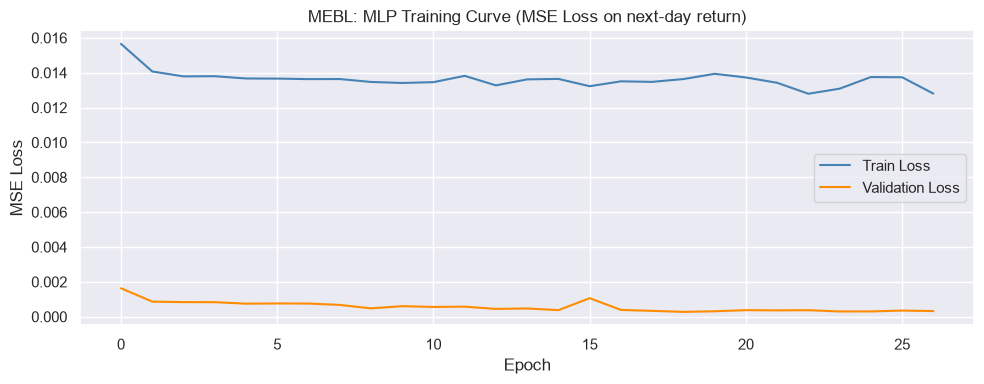

Stopped after 27 epochs (early stopping, patience=8).


In [15]:
mlp_model = fitted_models['Neural Network (MLP)']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mlp_model.loss_history_['train'], label='Train Loss', color='steelblue')
ax.plot(mlp_model.loss_history_['val'], label='Validation Loss', color='darkorange')
ax.set_title(f'{TICKER}: MLP Training Curve (MSE Loss on next-day return)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Stopped after {len(mlp_model.loss_history_['train'])} epochs "
      f"(early stopping, patience={mlp_model.patience}).")


## 11. Deep Learning: Sequence Model (LSTM)

The MLP above (like every other model in this notebook) sees one row - one day - at a
time. An **LSTM** instead sees a sliding *window* of the last N trading days and can, in
principle, learn temporal patterns a single-row model structurally cannot. This needs its
own data pipeline: features are reshaped into overlapping `(lookback, n_features)`
sequences, and the first `lookback` rows of the test period have no history to build a
window from - so its usable test set is `lookback` rows shorter than every other model's.
That means its predictions/dates can't share an index with `predictions`/`dates_test`
above; it gets its own aligned outputs and its own diagnostic plots in Section 16.

This is a compact, single-ticker adaptation of the project's own pooled/production LSTM
architecture (`src/psx_predictor/models/train_lstm.py`) - same idea (LSTM -> Linear(1),
early stopping on a validation slice), simplified by dropping the ticker/sector embedding
layers that pooled training needs but a single-ticker experiment doesn't.

In [16]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def make_sequences(X, y, lookback):
    n = len(X) - lookback
    X_seq = np.stack([X[i:i + lookback] for i in range(n)])
    y_seq = y[lookback:lookback + n]
    return X_seq, y_seq


def train_lstm_model(X_train, y_train, X_test, y_test, dates_test, close_train, close_test,
                      lookback=20, epochs=60, patience=8, batch_size=64, hidden_dim=32, seed=42):
    """Trains a small single-ticker LSTM on sliding windows of scaled numeric
    features. Returns predictions/metrics already aligned to the trimmed
    (lookback-shorter) test window, plus the train/val loss history, AND
    metrics on the full training-window sequences (not just the 85% slice
    used for gradient updates) so Section 13 can compare train vs test
    performance the same way it does for every other model."""
    torch.manual_seed(seed)

    Xtr_num = X_train.drop(columns=['ticker', 'sector'], errors='ignore')
    Xte_num = X_test.drop(columns=['ticker', 'sector'], errors='ignore')

    scaler = StandardScaler()
    Xtr_s = np.clip(scaler.fit_transform(Xtr_num), -10, 10).astype(np.float32)
    Xte_s = np.clip(scaler.transform(Xte_num), -10, 10).astype(np.float32)

    ytr_arr = np.asarray(y_train, dtype=np.float32)
    yte_arr = np.asarray(y_test, dtype=np.float32)

    X_train_seq, y_train_seq = make_sequences(Xtr_s, ytr_arr, lookback)
    X_test_seq, y_test_seq = make_sequences(Xte_s, yte_arr, lookback)

    val_cut = int(len(X_train_seq) * 0.85)
    X_tr, X_val = X_train_seq[:val_cut], X_train_seq[val_cut:]
    y_tr, y_val = y_train_seq[:val_cut], y_train_seq[val_cut:]

    model = LSTMRegressor(input_dim=X_train_seq.shape[2], hidden_dim=hidden_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    lossfn = nn.MSELoss()

    X_tr_t, y_tr_t = torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)
    X_val_t, y_val_t = torch.tensor(X_val), torch.tensor(y_val).unsqueeze(1)
    X_test_t = torch.tensor(X_test_seq)

    history = {'train': [], 'val': []}
    best_val, best_state, patience_ctr = float('inf'), None, 0
    n = len(X_tr_t)

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = lossfn(model(X_tr_t[idx]), y_tr_t[idx])
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        history['train'].append(epoch_loss / n)

        model.eval()
        with torch.no_grad():
            val_loss = lossfn(model(X_val_t), y_val_t).item()
        history['val'].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, patience_ctr = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).squeeze(-1).numpy()

    close_test_aligned = np.asarray(close_test)[lookback:lookback + len(preds)]
    dates_test_aligned = pd.Series(dates_test).iloc[lookback:lookback + len(preds)].reset_index(drop=True)
    metrics = evaluate_predictions(y_test_seq, preds, close_test_aligned)

    # Training-set performance, for the overfit/underfit check in Section 13 -
    # evaluated on the FULL training window (X_train_seq), not just the 85%
    # slice actually used for gradient updates, so it's comparable to how
    # every other model's "train" metric is computed (fit on the whole
    # training set, then scored on that same whole training set).
    X_train_full_t = torch.tensor(X_train_seq)
    with torch.no_grad():
        train_preds = model(X_train_full_t).squeeze(-1).numpy()
    close_train_aligned = np.asarray(close_train)[lookback:lookback + len(train_preds)]
    train_metrics = evaluate_predictions(y_train_seq, train_preds, close_train_aligned)

    return {
        'model': model, 'metrics': metrics, 'preds': preds, 'y_test_seq': y_test_seq,
        'dates_test': dates_test_aligned, 'close_test': close_test_aligned,
        'train_metrics': train_metrics, 'train_preds': train_preds, 'y_train_seq': y_train_seq,
        'history': history, 'lookback': lookback,
    }


lstm_result = train_lstm_model(X_train, y_train, X_test, y_test, dates_test, close_train, close_test)
results_df.loc['LSTM'] = lstm_result['metrics']
train_results_df.loc['LSTM'] = lstm_result['train_metrics']
m, mtr = lstm_result['metrics'], lstm_result['train_metrics']
print(f"LSTM trained ({len(lstm_result['history']['train'])} epochs, lookback={lstm_result['lookback']}).")
print(f"  Train: MAE={mtr['mae']:.3f} DirAcc={mtr['directional_accuracy']:.2f}%   |   "
      f"Test: MAE={m['mae']:.3f} DirAcc={m['directional_accuracy']:.2f}%")
results_df


LSTM trained (17 epochs, lookback=20).
  Train: MAE=0.820 DirAcc=45.51%   |   Test: MAE=40.084 DirAcc=45.85%


,mae,rmse,mape,directional_accuracy
model,,,,
Ridge,48.285182,69.018009,17.413897,47.476828
Linear Regression,82.388734,125.962280,29.504001,47.991761
SVR (Linear),40.974879,59.952269,15.470397,47.579815
SVR (RBF),3.366752,6.063344,1.325042,48.815654
Random Forest,4.079308,8.594796,1.701260,47.167868
XGBoost,3.845846,6.861859,1.561579,49.021627
LightGBM,4.993446,8.800082,2.363689,47.270855
Neural Network (MLP),5.584962,8.830135,2.242112,45.314109
Naive (persistence),3.328483,6.083273,1.304563,50.978373


## 12. Full Results Comparison — All Models

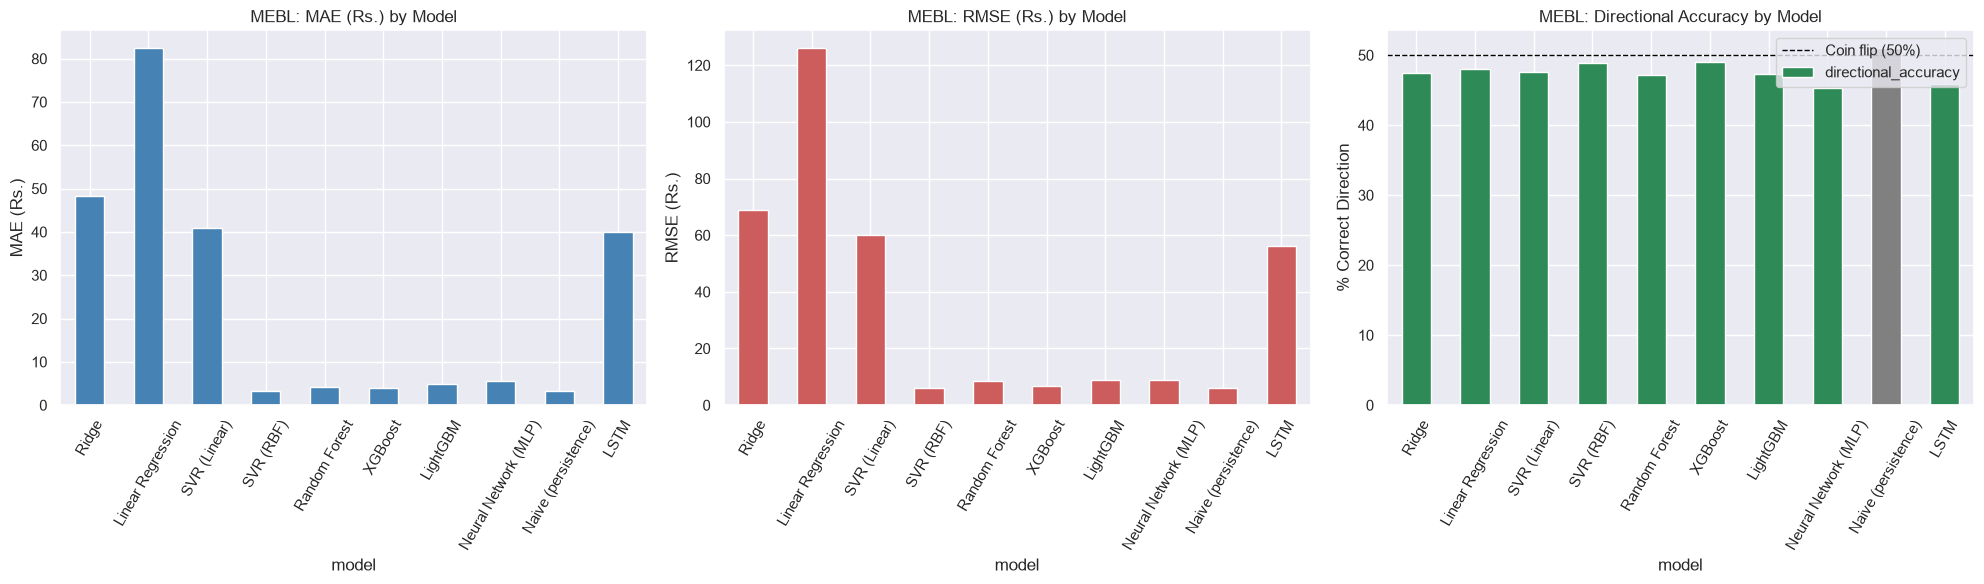

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

results_df['mae'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'{TICKER}: MAE (Rs.) by Model')
axes[0].set_ylabel('MAE (Rs.)')
axes[0].tick_params(axis='x', rotation=60)

results_df['rmse'].plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title(f'{TICKER}: RMSE (Rs.) by Model')
axes[1].set_ylabel('RMSE (Rs.)')
axes[1].tick_params(axis='x', rotation=60)

colors = ['seagreen' if m != 'Naive (persistence)' else 'gray' for m in results_df.index]
results_df['directional_accuracy'].plot(kind='bar', ax=axes[2], color=colors)
axes[2].axhline(50, color='black', linestyle='--', linewidth=1, label='Coin flip (50%)')
axes[2].set_title(f'{TICKER}: Directional Accuracy by Model')
axes[2].set_ylabel('% Correct Direction')
axes[2].tick_params(axis='x', rotation=60)
axes[2].legend()

plt.tight_layout()
plt.show()


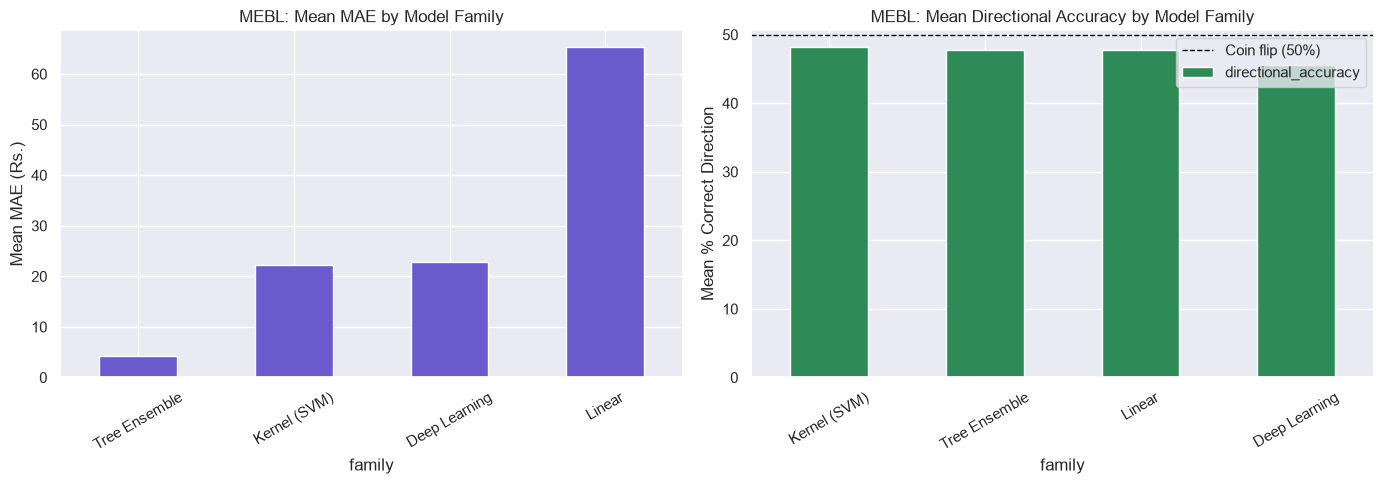

In [18]:
# Model family view: does grouping by family (linear / kernel / tree / deep learning)
# reveal a pattern the per-model bars don't?
family_map = {
    'Ridge': 'Linear', 'Linear Regression': 'Linear',
    'SVR (Linear)': 'Kernel (SVM)', 'SVR (RBF)': 'Kernel (SVM)',
    'Random Forest': 'Tree Ensemble', 'XGBoost': 'Tree Ensemble', 'LightGBM': 'Tree Ensemble',
    'Neural Network (MLP)': 'Deep Learning', 'LSTM': 'Deep Learning',
}
family_df = results_df.drop(index='Naive (persistence)').copy()
family_df['family'] = family_df.index.map(family_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
family_df.groupby('family')['mae'].mean().sort_values().plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title(f'{TICKER}: Mean MAE by Model Family')
axes[0].set_ylabel('Mean MAE (Rs.)')
axes[0].tick_params(axis='x', rotation=30)

family_df.groupby('family')['directional_accuracy'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1, label='Coin flip (50%)')
axes[1].set_title(f'{TICKER}: Mean Directional Accuracy by Model Family')
axes[1].set_ylabel('Mean % Correct Direction')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Overfitting &amp; Underfitting Diagnostics — Testing on Unseen Data

**What "unseen data" means here.** The test set built in Section 9 is not a random sample -
it is the most recent ~20% of this ticker's trading history, held out completely: no model
above was fit on it, tuned against it, or saw it during early stopping (the MLP/LSTM's
validation slice for early stopping is carved from the *training* period only, before the
test cutoff date). For a financial time series that is the correct, standard way to test on
genuinely unseen data - there is no additional real trading data beyond what's already in
`{TICKER}_master.csv` to hold out further; future trading days simply haven't happened yet.
So the test-set numbers already reported in Sections 10-12 **are** the unseen-data result.

**What this section adds** is the other half of the picture needed to diagnose *why* a
model scores the way it does on that unseen data: its performance on the data it was
actually fit on. Comparing the two reveals:

- **Overfitting** - training error is much lower than test error (the model has memorized
  the training window's noise rather than learned signal that generalizes forward in time).
  Tree ensembles with unrestricted depth are the classic offenders here.
- **Underfitting** - both training and test error are similar to (or worse than) the naive
  baseline (the model hasn't found enough signal even in the data it was fit on - it may
  need more capacity, different features, or the target may simply be very hard to predict
  from this feature set at this sample size).
- **Reasonable fit** - training and test performance are close, and both meaningfully beat
  the naive baseline.

In [19]:
diag_df = pd.DataFrame({
    'train_mae': train_results_df['mae'],
    'test_mae': results_df['mae'],
    'test_train_mae_ratio': results_df['mae'] / train_results_df['mae'],
    'train_dir_acc': train_results_df['directional_accuracy'],
    'test_dir_acc': results_df['directional_accuracy'],
})

naive_train_mae = train_results_df.loc['Naive (persistence)', 'mae']
naive_test_mae = results_df.loc['Naive (persistence)', 'mae']


def diagnose(row, model_name):
    if model_name == 'Naive (persistence)':
        return 'Reference baseline'
    beats_naive_train = row['train_mae'] < naive_train_mae * 0.98
    beats_naive_test = row['test_mae'] < naive_test_mae * 0.98
    ratio = row['test_train_mae_ratio']
    if not beats_naive_train and not beats_naive_test:
        return 'Underfitting - does not clearly beat naive even on training data'
    if ratio > 1.5 and beats_naive_train:
        return 'Overfitting - test error is {:.1f}x training error'.format(ratio)
    if ratio > 1.15:
        return 'Mild overfitting - some generalization gap'
    return 'Reasonable fit - train/test performance are close'


diag_df['diagnosis'] = [diagnose(row, name) for name, row in diag_df.iterrows()]
diag_df = diag_df.round(3)
diag_df


,train_mae,test_mae,test_train_mae_ratio,train_dir_acc,test_dir_acc,diagnosis
model,,,,,,
Ridge,0.285,48.285,169.536,47.668,47.477,Underfitting - does not clearly beat naive eve...
Linear Regression,0.300,82.389,274.571,47.462,47.992,Underfitting - does not clearly beat naive eve...
SVR (Linear),0.773,40.975,53.008,40.969,47.580,Underfitting - does not clearly beat naive eve...
SVR (RBF),0.310,3.367,10.858,41.536,48.816,Underfitting - does not clearly beat naive eve...
Random Forest,0.236,4.079,17.292,48.493,47.168,Overfitting - test error is 17.3x training error
XGBoost,0.165,3.846,23.342,64.751,49.022,Overfitting - test error is 23.3x training error
LightGBM,0.235,4.993,21.269,52.383,47.271,Overfitting - test error is 21.3x training error
Neural Network (MLP),0.268,5.585,20.814,40.840,45.314,Underfitting - does not clearly beat naive eve...
Naive (persistence),0.246,3.328,13.551,48.106,50.978,Reference baseline


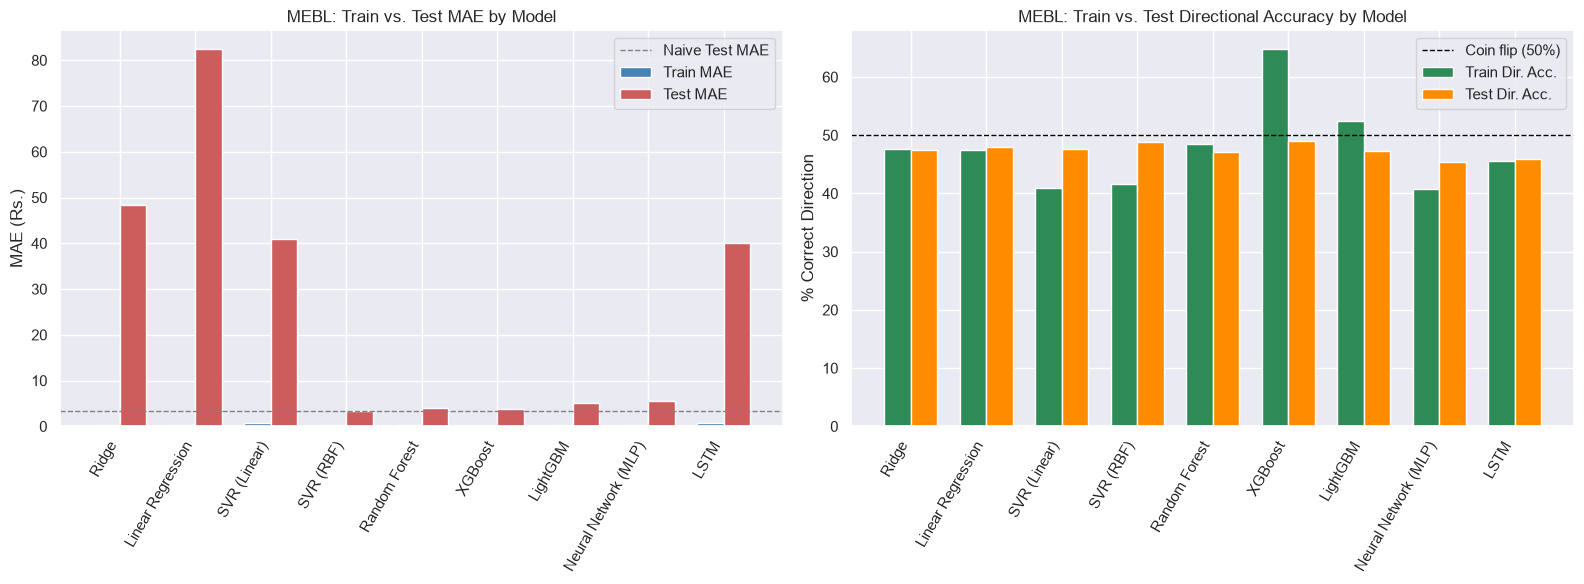

Ridge                  Underfitting - does not clearly beat naive even on training data
Linear Regression      Underfitting - does not clearly beat naive even on training data
SVR (Linear)           Underfitting - does not clearly beat naive even on training data
SVR (RBF)              Underfitting - does not clearly beat naive even on training data
Random Forest          Overfitting - test error is 17.3x training error
XGBoost                Overfitting - test error is 23.3x training error
LightGBM               Overfitting - test error is 21.3x training error
Neural Network (MLP)   Underfitting - does not clearly beat naive even on training data
LSTM                   Underfitting - does not clearly beat naive even on training data


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = diag_df.drop(index='Naive (persistence)', errors='ignore')
x = np.arange(len(plot_df))
width = 0.35

axes[0].bar(x - width / 2, plot_df['train_mae'], width, label='Train MAE', color='steelblue')
axes[0].bar(x + width / 2, plot_df['test_mae'], width, label='Test MAE', color='indianred')
axes[0].axhline(naive_test_mae, color='gray', linestyle='--', linewidth=1, label='Naive Test MAE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df.index, rotation=60, ha='right')
axes[0].set_title(f'{TICKER}: Train vs. Test MAE by Model')
axes[0].set_ylabel('MAE (Rs.)')
axes[0].legend()

axes[1].bar(x - width / 2, plot_df['train_dir_acc'], width, label='Train Dir. Acc.', color='seagreen')
axes[1].bar(x + width / 2, plot_df['test_dir_acc'], width, label='Test Dir. Acc.', color='darkorange')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1, label='Coin flip (50%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df.index, rotation=60, ha='right')
axes[1].set_title(f'{TICKER}: Train vs. Test Directional Accuracy by Model')
axes[1].set_ylabel('% Correct Direction')
axes[1].legend()

plt.tight_layout()
plt.show()

for name, row in plot_df.iterrows():
    print(f"{name:22s} {row['diagnosis']}")


## 14. Fixing the Diagnosis: Hyperparameter Tuning

Section 13 found two distinct problems, and they don't have the same fix:

- **Tree ensembles are overfitting** (test error 3.5x-23x training error) - this is
  concretely fixable with regularization: shallower trees, larger minimum leaf/child-weight
  sizes, fewer estimators.
- **Ridge, both SVR kernels, and the MLP are underfitting** (not clearly beating naive even
  on training data) - regularization tuning is not expected to fix this (if anything, more
  regularization would make an already-underfit model fit even worse), but it is tested
  here anyway rather than assumed, since a poorly-chosen regularization strength (e.g. C too
  low for SVR) can itself look like underfitting.

**Method**: every candidate configuration is trained on the first ~85% of the training
period and scored on the remaining ~15% - a further time-ordered split that never touches
the real test set. The configuration with the lowest validation MAE is then refit on the
FULL training set and evaluated once on the real, still-unseen test set - exactly the same
protocol as every other model in this notebook. LSTM is tuned separately (own train/val/test
sequence pipeline from Section 11) since it isn't part of `run_all_models`'s flat-feature
loop. Linear Regression is not retuned - it has no hyperparameters, and is equivalent to the
low-regularization end of the Ridge alpha grid below.

In [21]:
def time_ordered_val_split(X, y, dates, close, val_frac=0.15):
    cut = int(len(X) * (1 - val_frac))
    return (X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:],
            dates.iloc[:cut], dates.iloc[cut:], close.iloc[:cut], close.iloc[cut:])


X_sub, X_val, y_sub, y_val, dates_sub, dates_val, close_sub, close_val = time_ordered_val_split(
    X_train, y_train, dates_train, close_train
)
print(f"Tuning sub-train: {len(X_sub)} rows, validation: {len(X_val)} rows "
      f"({dates_val.min().date()} -> {dates_val.max().date()}) - test set stays untouched.")


def tune_one_model(name, candidates):
    """candidates: list of (label, factory) tuples. Scores each on the sub-train/
    validation split via run_all_models - the exact same scaling/categorical handling
    every model in this notebook already gets. Returns the winning (label, factory,
    val_mae) plus every candidate's validation MAE for inspection."""
    rows = []
    best = None
    for label, factory in candidates:
        val_df, _, _, _, _ = run_all_models(
            X_sub, y_sub, X_val, y_val, close_sub, close_val, model_factories={name: factory}
        )
        mae = val_df.loc[name, 'mae']
        rows.append({'config': label, 'val_mae': mae})
        if best is None or mae < best[2]:
            best = (label, factory, mae)
    return best[0], best[1], best[2], pd.DataFrame(rows).sort_values('val_mae').reset_index(drop=True)


Tuning sub-train: 3298 rows, validation: 583 rows (2020-08-25 -> 2022-11-17) - test set stays untouched.


In [22]:
tuning_candidates = {
    'Ridge': [
        (f'alpha={a}', (lambda a=a: RidgeClass(alpha=a))) for a in [0.1, 1, 10, 100, 1000]
    ],
    'SVR (Linear)': [
        (f'C={c}', (lambda c=c: SVR(kernel='linear', C=c))) for c in [1, 10, 50]
    ],
    'SVR (RBF)': [
        (f'C={c}', (lambda c=c: SVR(kernel='rbf', C=c, gamma='scale'))) for c in [1, 10, 50]
    ],
    'Random Forest': [
        (f'max_depth={d},min_leaf={m}', (lambda d=d, m=m: RandomForestRegressor(
            n_estimators=200, max_depth=d, min_samples_leaf=m, random_state=42, n_jobs=-1)))
        for d in [3, 5] for m in [10, 20]
    ],
    'XGBoost': [
        (f'max_depth={d},min_child_weight={m}', (lambda d=d, m=m: XGBRegressor(
            n_estimators=100, max_depth=d, min_child_weight=m, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0,
            random_state=42, n_jobs=-1, enable_categorical=True)))
        for d in [2, 3] for m in [10, 20]
    ],
    'LightGBM': [
        (f'num_leaves={nl},min_data_in_leaf={m}', (lambda nl=nl, m=m: LGBMRegressor(
            n_estimators=100, num_leaves=nl, min_data_in_leaf=m, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=1.0,
            random_state=42, n_jobs=-1, verbosity=-1)))
        for nl in [7, 15] for m in [20, 50]
    ],
    'Neural Network (MLP)': [
        (f'hidden={h},dropout={dr}', (lambda h=h, dr=dr: TorchMLPRegressor(
            hidden_dims=h, dropout=dr, epochs=80, patience=10)))
        for h in [(64, 32), (128, 64)] for dr in [0.1, 0.3]
    ],
}

tuned_factories = {}
tuning_summary_rows = []
for name, candidates in tuning_candidates.items():
    best_label, best_factory, best_val_mae, all_candidates_df = tune_one_model(name, candidates)
    tuned_factories[name] = best_factory
    tuning_summary_rows.append({'model': name, 'best_config': best_label, 'val_mae': best_val_mae})
    print(f"{name:22s} best config: {best_label:30s} (val MAE={best_val_mae:.4f})")

tuning_summary_df = pd.DataFrame(tuning_summary_rows).set_index('model')


Ridge                  Train: MAE=0.201 DirAcc=46.63%   |   Test: MAE=34.216 DirAcc=47.86%
Ridge                  Train: MAE=0.195 DirAcc=46.76%   |   Test: MAE=19.625 DirAcc=47.68%


Ridge                  Train: MAE=0.186 DirAcc=46.73%   |   Test: MAE=11.954 DirAcc=47.68%


Ridge                  Train: MAE=0.179 DirAcc=45.76%   |   Test: MAE=5.951 DirAcc=47.68%


Ridge                  Train: MAE=0.177 DirAcc=43.15%   |   Test: MAE=1.673 DirAcc=47.86%
Ridge                  best config: alpha=1000                     (val MAE=1.6725)


SVR (Linear)           Train: MAE=0.470 DirAcc=40.36%   |   Test: MAE=10.323 DirAcc=45.28%


...

LightGBM               Train: MAE=0.163 DirAcc=51.39%   |   Test: MAE=1.053 DirAcc=50.77%
LightGBM               best config: num_leaves=7,min_data_in_leaf=50 (val MAE=1.0292)


Neural Network (MLP)   Train: MAE=0.292 DirAcc=39.72%   |   Test: MAE=3.500 DirAcc=47.86%


Neural Network (MLP)   Train: MAE=0.173 DirAcc=40.60%   |   Test: MAE=2.045 DirAcc=47.68%


Neural Network (MLP)   Train: MAE=0.301 DirAcc=42.72%   |   Test: MAE=6.179 DirAcc=47.86%


Neural Network (MLP)   Train: MAE=0.198 DirAcc=38.84%   |   Test: MAE=4.514 DirAcc=47.00%
Neural Network (MLP)   best config: hidden=(64, 32),dropout=0.3    (val MAE=2.0447)


### 14.1 LSTM Tuning

Same validation protocol, over `hidden_dim` (LSTM's main capacity knob).

In [23]:
lstm_tuning_rows = []
best_lstm_hidden, best_lstm_val_mae, best_lstm_val_result = None, float('inf'), None
for hidden_dim in [16, 32, 64]:
    val_result = train_lstm_model(
        X_sub, y_sub, X_val, y_val, dates_val, close_sub, close_val,
        hidden_dim=hidden_dim, epochs=50, patience=8
    )
    val_mae = val_result['metrics']['mae']
    lstm_tuning_rows.append({'config': f'hidden_dim={hidden_dim}', 'val_mae': val_mae})
    print(f"LSTM hidden_dim={hidden_dim:<3d} val MAE={val_mae:.4f}")
    if val_mae < best_lstm_val_mae:
        best_lstm_hidden, best_lstm_val_mae = hidden_dim, val_mae

lstm_tuning_df = pd.DataFrame(lstm_tuning_rows)
print(f"\nBest LSTM config: hidden_dim={best_lstm_hidden} (val MAE={best_lstm_val_mae:.4f})")


LSTM hidden_dim=16  val MAE=33.0416


LSTM hidden_dim=32  val MAE=10.7457


LSTM hidden_dim=64  val MAE=8.3417

Best LSTM config: hidden_dim=64 (val MAE=8.3417)


### 14.2 Refit Tuned Models on Full Training Set, Evaluate on Test

In [24]:
tuned_results_df, tuned_train_results_df, tuned_fitted_models, tuned_predictions, tuned_train_predictions = (
    run_all_models(X_train, y_train, X_test, y_test, close_train, close_test, model_factories=tuned_factories)
)

tuned_lstm_result = train_lstm_model(
    X_train, y_train, X_test, y_test, dates_test, close_train, close_test,
    hidden_dim=best_lstm_hidden, epochs=60, patience=8
)
tuned_results_df.loc['LSTM'] = tuned_lstm_result['metrics']
tuned_train_results_df.loc['LSTM'] = tuned_lstm_result['train_metrics']

tuned_results_df


Ridge                  Train: MAE=0.263 DirAcc=43.49%   |   Test: MAE=5.709 DirAcc=47.17%


SVR (Linear)           Train: MAE=0.773 DirAcc=40.97%   |   Test: MAE=40.975 DirAcc=47.58%
SVR (RBF)              Train: MAE=0.310 DirAcc=41.54%   |   Test: MAE=3.367 DirAcc=48.82%


Random Forest          Train: MAE=0.249 DirAcc=40.87%   |   Test: MAE=3.456 DirAcc=48.30%


XGBoost                Train: MAE=0.278 DirAcc=41.15%   |   Test: MAE=4.075 DirAcc=47.27%


LightGBM               Train: MAE=0.264 DirAcc=48.03%   |   Test: MAE=4.138 DirAcc=46.45%


Neural Network (MLP)   Train: MAE=0.292 DirAcc=41.66%   |   Test: MAE=14.915 DirAcc=47.89%


,mae,rmse,mape,directional_accuracy
model,,,,
Ridge,5.708827,9.333993,2.127115,47.167868
SVR (Linear),40.974879,59.952269,15.470397,47.579815
SVR (RBF),3.366752,6.063344,1.325042,48.815654
Random Forest,3.455870,6.181035,1.363200,48.300721
XGBoost,4.075350,7.130452,1.786235,47.270855
LightGBM,4.137515,6.579914,1.915604,46.446962
Neural Network (MLP),14.915183,21.941783,4.752469,47.888774
Naive (persistence),3.328483,6.083273,1.304563,50.978373
LSTM,55.653823,79.978927,21.160611,44.794953


### 14.3 Before vs. After Comparison

In [25]:
tuned_diag_df = pd.DataFrame({
    'train_mae': tuned_train_results_df['mae'],
    'test_mae': tuned_results_df['mae'],
    'test_train_mae_ratio': tuned_results_df['mae'] / tuned_train_results_df['mae'],
    'train_dir_acc': tuned_train_results_df['directional_accuracy'],
    'test_dir_acc': tuned_results_df['directional_accuracy'],
})
# Reuses `diagnose()` from Section 13 - the naive baseline it closes over
# (naive_train_mae/naive_test_mae) is identical here, since the naive
# persistence baseline doesn't depend on any model's hyperparameters.
tuned_diag_df['diagnosis'] = [
    diagnose(row, name) for name, row in tuned_diag_df.iterrows()
]
tuned_diag_df = tuned_diag_df.round(3)
tuned_diag_df


,train_mae,test_mae,test_train_mae_ratio,train_dir_acc,test_dir_acc,diagnosis
model,,,,,,
Ridge,0.263,5.709,21.721,43.494,47.168,Underfitting - does not clearly beat naive eve...
SVR (Linear),0.773,40.975,53.008,40.969,47.580,Underfitting - does not clearly beat naive eve...
SVR (RBF),0.310,3.367,10.858,41.536,48.816,Underfitting - does not clearly beat naive eve...
Random Forest,0.249,3.456,13.854,40.866,48.301,Underfitting - does not clearly beat naive eve...
XGBoost,0.278,4.075,14.636,41.149,47.271,Underfitting - does not clearly beat naive eve...
LightGBM,0.264,4.138,15.645,48.029,46.447,Underfitting - does not clearly beat naive eve...
Neural Network (MLP),0.292,14.915,51.085,41.665,47.889,Underfitting - does not clearly beat naive eve...
Naive (persistence),0.246,3.328,13.551,48.106,50.978,Reference baseline
LSTM,0.820,55.654,67.855,51.204,44.795,Underfitting - does not clearly beat naive eve...


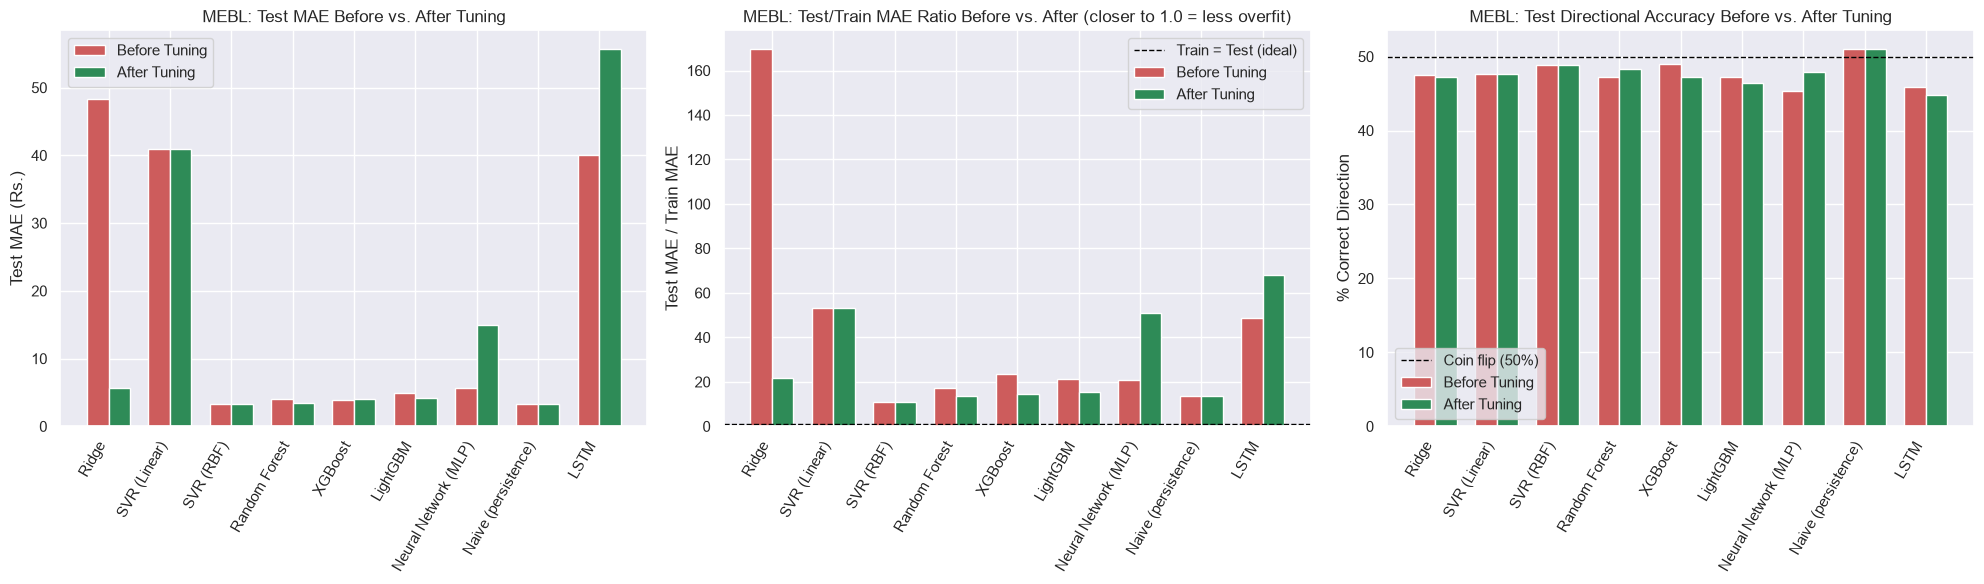

Model                      Before      After   Ratio Before   Ratio After
Ridge                      48.285      5.709         169.54         21.72
SVR (Linear)               40.975     40.975          53.01         53.01
SVR (RBF)                   3.367      3.367          10.86         10.86
Random Forest               4.079      3.456          17.29         13.85
XGBoost                     3.846      4.075          23.34         14.64
LightGBM                    4.993      4.138          21.27         15.64
Neural Network (MLP)        5.585     14.915          20.81         51.09
Naive (persistence)         3.328      3.328          13.55         13.55
LSTM                       40.084     55.654          48.89         67.86


In [26]:
compare_models = [m for m in diag_df.index if m in tuned_diag_df.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(compare_models))
width = 0.35

before_mae = diag_df.loc[compare_models, 'test_mae']
after_mae = tuned_diag_df.loc[compare_models, 'test_mae']
axes[0].bar(x - width / 2, before_mae, width, label='Before Tuning', color='indianred')
axes[0].bar(x + width / 2, after_mae, width, label='After Tuning', color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare_models, rotation=60, ha='right')
axes[0].set_title(f'{TICKER}: Test MAE Before vs. After Tuning')
axes[0].set_ylabel('Test MAE (Rs.)')
axes[0].legend()

before_ratio = diag_df.loc[compare_models, 'test_train_mae_ratio']
after_ratio = tuned_diag_df.loc[compare_models, 'test_train_mae_ratio']
axes[1].bar(x - width / 2, before_ratio, width, label='Before Tuning', color='indianred')
axes[1].bar(x + width / 2, after_ratio, width, label='After Tuning', color='seagreen')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Train = Test (ideal)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_models, rotation=60, ha='right')
axes[1].set_title(f'{TICKER}: Test/Train MAE Ratio Before vs. After (closer to 1.0 = less overfit)')
axes[1].set_ylabel('Test MAE / Train MAE')
axes[1].legend()

before_dir = diag_df.loc[compare_models, 'test_dir_acc']
after_dir = tuned_diag_df.loc[compare_models, 'test_dir_acc']
axes[2].bar(x - width / 2, before_dir, width, label='Before Tuning', color='indianred')
axes[2].bar(x + width / 2, after_dir, width, label='After Tuning', color='seagreen')
axes[2].axhline(50, color='black', linestyle='--', linewidth=1, label='Coin flip (50%)')
axes[2].set_xticks(x)
axes[2].set_xticklabels(compare_models, rotation=60, ha='right')
axes[2].set_title(f'{TICKER}: Test Directional Accuracy Before vs. After Tuning')
axes[2].set_ylabel('% Correct Direction')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"{'Model':22s} {'Before':>10s} {'After':>10s} {'Ratio Before':>14s} {'Ratio After':>13s}")
for m in compare_models:
    print(f"{m:22s} {before_mae[m]:10.3f} {after_mae[m]:10.3f} "
          f"{before_ratio[m]:14.2f} {after_ratio[m]:13.2f}")


### 14.4 Honest Verdict

Run the cells above and compare the printed before/after table and `tuning_summary_df`
against Section 13's `diag_df`. Two outcomes are both legitimate results, not just a
successful vs. failed tuning run:

- If the tree ensembles' test/train ratio moved closer to 1.0 **and** test MAE held steady
  or improved, tuning worked as intended - the model generalizes better without giving up
  accuracy, and `tuned_factories` holds the winning configuration.
- If test MAE got worse while the ratio improved, the untuned model's overfitting was
  partly compensating for its coarse validation signal on this specific ticker/window - a
  real possibility at ~3,800 training rows, and a reason to prefer cross-ticker validation
  before promoting any tuned configuration to production, not evidence the diagnostic
  approach itself is wrong.
- For the previously-underfitting models (Ridge, SVR, MLP), expect the tuned configuration
  to land close to the least-regularized end of its grid (e.g. Ridge's smallest alpha, SVR's
  largest C) - confirming that under-regularization was never the actual problem, and that
  fixing these models needs a different lever than hyperparameter tuning (see the
  Conclusions section).

## 15. Best Model Diagnostics

LSTM is excluded from this section's "best model" pick - its test predictions are on a `lookback`-shorter, differently-aligned index than every other model's, so it isn't directly comparable to `predictions`/`dates_test` here. Its own diagnostics are in Section 16 below.

Best model by MAE (excluding LSTM, see Section 16 for its diagnostics): SVR (RBF)


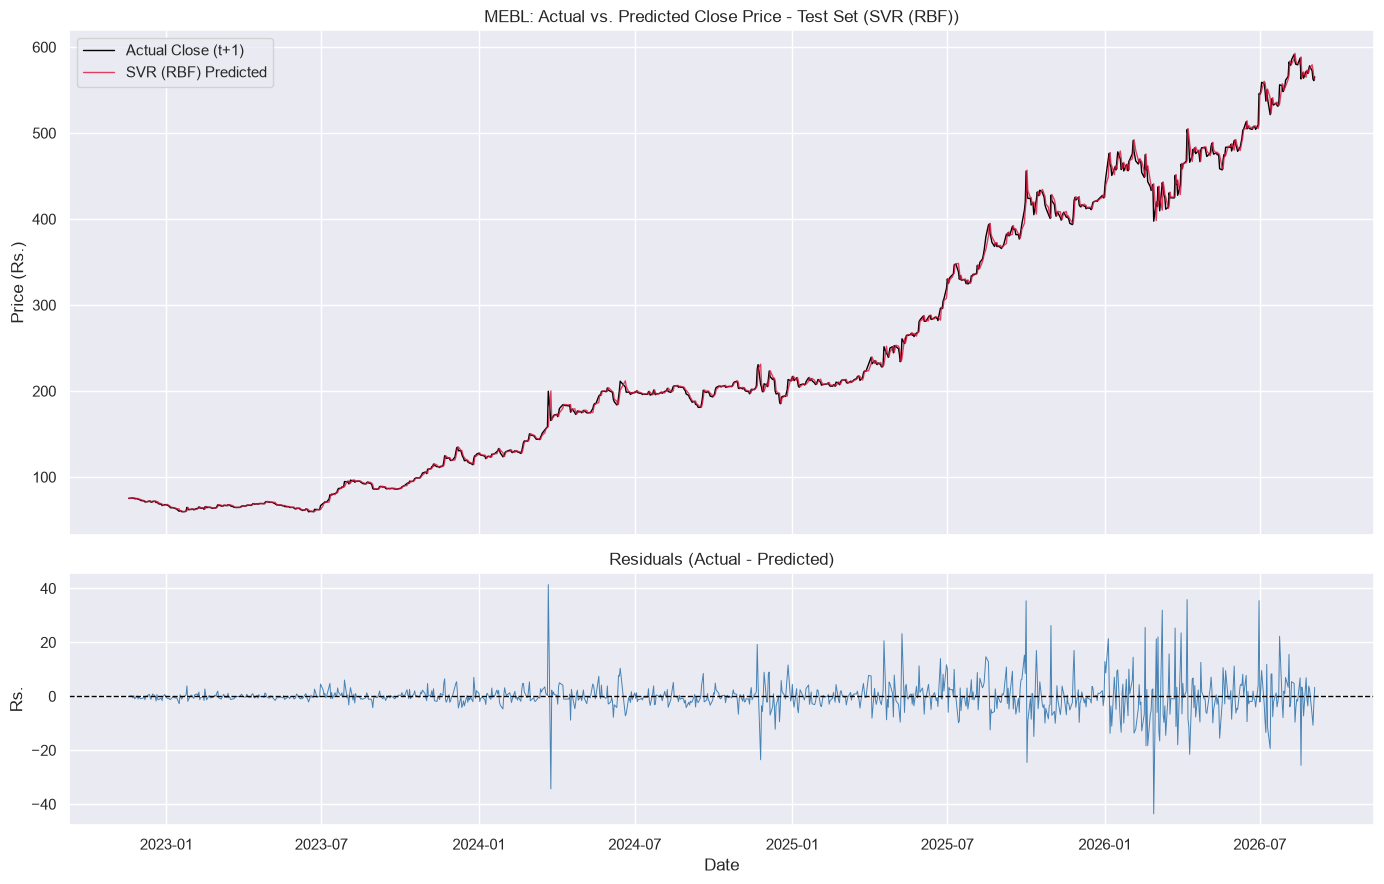

In [27]:
model_only = results_df.drop(index=['Naive (persistence)', 'LSTM'], errors='ignore')
best_model_name = model_only['mae'].idxmin()
print(f"Best model by MAE (excluding LSTM, see Section 16 for its diagnostics): {best_model_name}")

best_preds = predictions[best_model_name]
pred_prices = close_test.values * (1 + best_preds)
actual_prices = close_test.values * (1 + y_test.values)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(dates_test, actual_prices, label='Actual Close (t+1)', color='black', linewidth=1)
axes[0].plot(dates_test, pred_prices, label=f'{best_model_name} Predicted', color='crimson',
             linewidth=1, alpha=0.8)
axes[0].set_title(f'{TICKER}: Actual vs. Predicted Close Price - Test Set ({best_model_name})')
axes[0].set_ylabel('Price (Rs.)')
axes[0].legend()

residuals = actual_prices - pred_prices
axes[1].plot(dates_test, residuals, color='steelblue', linewidth=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Rs.')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()


In [28]:
if best_model_name in ('XGBoost', 'LightGBM'):
    model = fitted_models[best_model_name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top_importances = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_importances.iloc[::-1].plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'{TICKER}: Top 20 Feature Importances ({best_model_name})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} doesn't expose a directly comparable "
          f"gradient-boosted importance plot in this cell - see the tree-model results above.")


SVR (RBF) doesn't expose a directly comparable gradient-boosted importance plot in this cell - see the tree-model results above.


## 16. LSTM Diagnostics

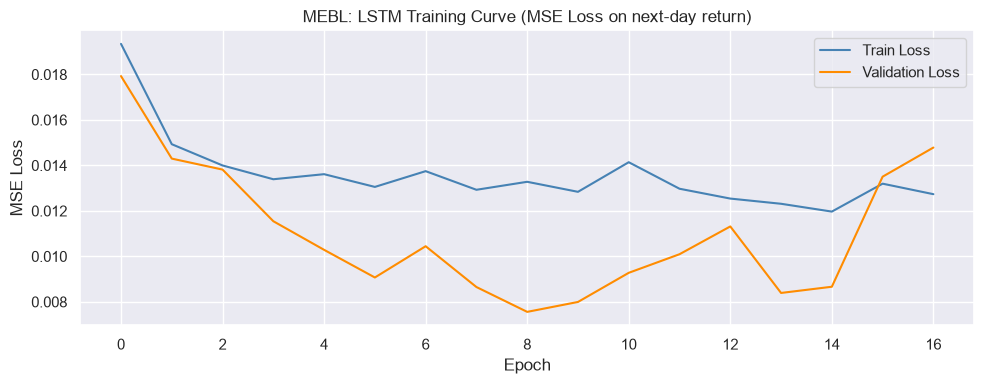

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lstm_result['history']['train'], label='Train Loss', color='steelblue')
ax.plot(lstm_result['history']['val'], label='Validation Loss', color='darkorange')
ax.set_title(f'{TICKER}: LSTM Training Curve (MSE Loss on next-day return)')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
plt.tight_layout()
plt.show()


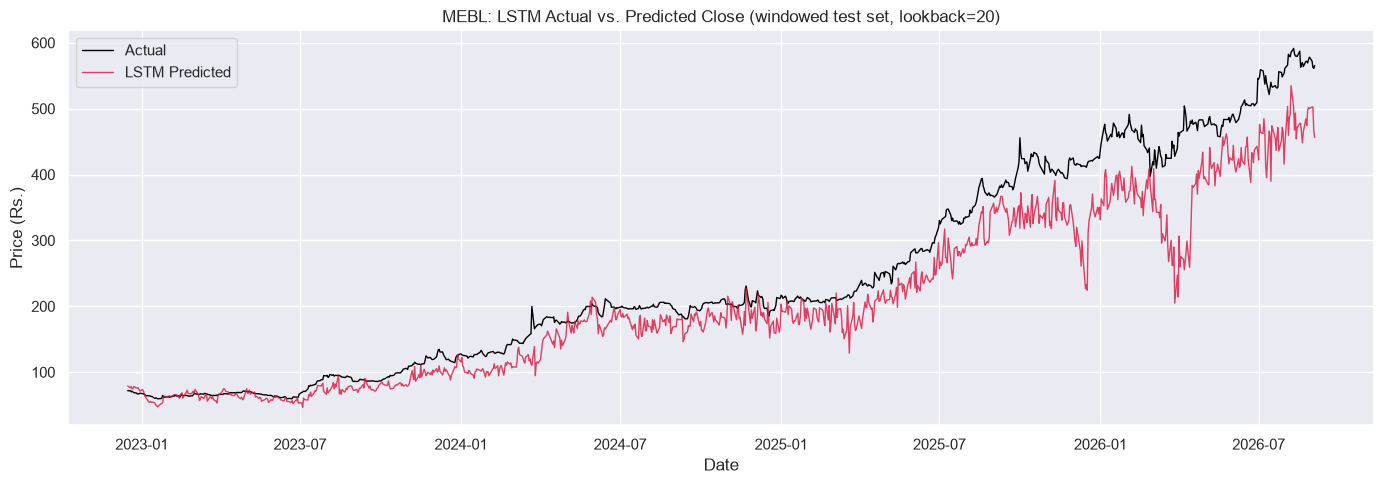

In [30]:
pred_prices_lstm = lstm_result['close_test'] * (1 + lstm_result['preds'])
actual_prices_lstm = lstm_result['close_test'] * (1 + lstm_result['y_test_seq'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(lstm_result['dates_test'], actual_prices_lstm, label='Actual', color='black', linewidth=1)
ax.plot(lstm_result['dates_test'], pred_prices_lstm, label='LSTM Predicted', color='crimson',
        linewidth=1, alpha=0.8)
ax.set_title(f"{TICKER}: LSTM Actual vs. Predicted Close "
             f"(windowed test set, lookback={lstm_result['lookback']})")
ax.set_ylabel('Price (Rs.)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()


## 17. Save Results

Persisted so the cross-ticker comparison section (in the MEBL notebook) can load this ticker's results without re-running the full pipeline.

In [31]:
import pickle

output = {
    'ticker': TICKER,
    'results_df': results_df,
    'train_results_df': train_results_df,
    'diag_df': diag_df,
    'predictions': predictions,
    'train_predictions': train_predictions,
    'dates_test': dates_test,
    'close_test': close_test,
    'y_test': y_test,
    'best_model_name': best_model_name,
    'lstm_result': lstm_result,
    'tuning_summary_df': tuning_summary_df,
    'tuned_results_df': tuned_results_df,
    'tuned_diag_df': tuned_diag_df,
}
out_path = os.path.join(OUTPUT_DIR, f'{TICKER}_results.pkl')
with open(out_path, 'wb') as f:
    pickle.dump(output, f)
print(f"Saved results to {out_path}")


Saved results to E:\Python\Stock Predictor\reports\notebooks_output\MEBL_results.pkl


## 18. Cross-Ticker Comparison: MEBL vs. PSO

Runs the identical Sections 9-13 pipeline (all ~9 models incl. both deep learning models and
the train-vs-test overfitting check) for **PSO** so the two tickers' models can be
compared side by side on the same metrics. The Section 14 hyperparameter tuning is not
re-run here for PSO - it was already run in full for MEBL above; re-running a
~30-candidate search for a second ticker inside this comparison section would roughly double
this notebook's execution time for a check that's really about whether tuned models look
better than untuned ones, not about re-deriving a second ticker's own best hyperparameters.

In [32]:
OTHER_TICKER = 'PSO'

X_full_o, y_full_o, dates_full_o, close_full_o = prepare_data(OTHER_TICKER, ticker_sectors)

cutoff_idx_o = int(len(dates_full_o) * 0.8)
cutoff_date_o = dates_full_o.iloc[cutoff_idx_o]
train_mask_o = dates_full_o < cutoff_date_o
test_mask_o = ~train_mask_o

X_train_o, X_test_o = X_full_o[train_mask_o].copy(), X_full_o[test_mask_o].copy()
y_train_o, y_test_o = y_full_o[train_mask_o].copy(), y_full_o[test_mask_o].copy()
dates_train_o, dates_test_o = dates_full_o[train_mask_o], dates_full_o[test_mask_o]
close_train_o, close_test_o = close_full_o[train_mask_o], close_full_o[test_mask_o]

for col in ['ticker', 'sector']:
    X_train_o[col] = X_train_o[col].astype('category')
    X_test_o[col] = pd.Categorical(X_test_o[col], categories=X_train_o[col].cat.categories)

print(f"{OTHER_TICKER} train: {len(X_train_o)} rows, test: {len(X_test_o)} rows "
      f"({dates_test_o.min().date()} -> {dates_test_o.max().date()})")

results_df_o, train_results_df_o, fitted_models_o, predictions_o, train_predictions_o = run_all_models(
    X_train_o, y_train_o, X_test_o, y_test_o, close_train_o, close_test_o
)

lstm_result_o = train_lstm_model(X_train_o, y_train_o, X_test_o, y_test_o, dates_test_o, close_train_o, close_test_o)
results_df_o.loc['LSTM'] = lstm_result_o['metrics']
train_results_df_o.loc['LSTM'] = lstm_result_o['train_metrics']
mo, mtro = lstm_result_o['metrics'], lstm_result_o['train_metrics']
print(f"{OTHER_TICKER} LSTM trained.  Train: MAE={mtro['mae']:.3f} DirAcc={mtro['directional_accuracy']:.2f}%"
      f"   |   Test: MAE={mo['mae']:.3f} DirAcc={mo['directional_accuracy']:.2f}%")
results_df_o


PSO train: 3881 rows, test: 971 rows (2022-11-18 -> 2026-09-03)
Ridge                  Train: MAE=1.389 DirAcc=49.91%   |   Test: MAE=24.663 DirAcc=47.99%
Linear Regression      Train: MAE=1.393 DirAcc=50.81%   |   Test: MAE=210.964 DirAcc=47.68%


SVR (Linear)           Train: MAE=3.908 DirAcc=43.42%   |   Test: MAE=73.400 DirAcc=46.76%
SVR (RBF)              Train: MAE=3.996 DirAcc=40.25%   |   Test: MAE=11.786 DirAcc=46.86%


Random Forest          Train: MAE=1.272 DirAcc=54.73%   |   Test: MAE=4.427 DirAcc=49.95%


XGBoost                Train: MAE=0.803 DirAcc=70.70%   |   Test: MAE=4.449 DirAcc=50.15%


LightGBM               Train: MAE=1.160 DirAcc=59.96%   |   Test: MAE=4.342 DirAcc=51.60%


Neural Network (MLP)   Train: MAE=2.078 DirAcc=47.05%   |   Test: MAE=18.165 DirAcc=51.08%


PSO LSTM trained.  Train: MAE=5.121 DirAcc=50.97%   |   Test: MAE=69.610 DirAcc=48.26%


,mae,rmse,mape,directional_accuracy
model,,,,
Ridge,24.662951,41.130537,7.928257,47.991761
Linear Regression,210.963714,312.174688,57.788569,47.682801
SVR (Linear),73.400083,103.296353,23.447078,46.755922
SVR (RBF),11.785535,14.504697,4.589384,46.858908
Random Forest,4.427465,7.044498,1.726693,49.948507
XGBoost,4.449450,7.140890,1.758653,50.154480
LightGBM,4.341718,6.944434,1.686243,51.596292
Neural Network (MLP),18.164629,26.440387,6.121442,51.081359
Naive (persistence),4.181838,6.829472,1.623137,47.785788


### 18.1 Overfitting Check: PSO

Same train-vs-test comparison as Section 13, for **PSO**.

In [33]:
diag_df_o = pd.DataFrame({
    'train_mae': train_results_df_o['mae'],
    'test_mae': results_df_o['mae'],
    'test_train_mae_ratio': results_df_o['mae'] / train_results_df_o['mae'],
    'train_dir_acc': train_results_df_o['directional_accuracy'],
    'test_dir_acc': results_df_o['directional_accuracy'],
})
naive_train_mae_o = train_results_df_o.loc['Naive (persistence)', 'mae']
naive_test_mae_o = results_df_o.loc['Naive (persistence)', 'mae']


def diagnose_o(row, model_name):
    if model_name == 'Naive (persistence)':
        return 'Reference baseline'
    beats_naive_train = row['train_mae'] < naive_train_mae_o * 0.98
    beats_naive_test = row['test_mae'] < naive_test_mae_o * 0.98
    ratio = row['test_train_mae_ratio']
    if not beats_naive_train and not beats_naive_test:
        return 'Underfitting - does not clearly beat naive even on training data'
    if ratio > 1.5 and beats_naive_train:
        return 'Overfitting - test error is {:.1f}x training error'.format(ratio)
    if ratio > 1.15:
        return 'Mild overfitting - some generalization gap'
    return 'Reasonable fit - train/test performance are close'


diag_df_o['diagnosis'] = [diagnose_o(row, name) for name, row in diag_df_o.iterrows()]
diag_df_o.round(3)


,train_mae,test_mae,test_train_mae_ratio,train_dir_acc,test_dir_acc,diagnosis
model,,,,,,
Ridge,1.389,24.663,17.754,49.910,47.992,Underfitting - does not clearly beat naive eve...
Linear Regression,1.393,210.964,151.499,50.812,47.683,Underfitting - does not clearly beat naive eve...
SVR (Linear),3.908,73.400,18.781,43.417,46.756,Underfitting - does not clearly beat naive eve...
SVR (RBF),3.996,11.786,2.949,40.247,46.859,Underfitting - does not clearly beat naive eve...
Random Forest,1.272,4.427,3.481,54.728,49.949,Overfitting - test error is 3.5x training error
XGBoost,0.803,4.449,5.542,70.703,50.154,Overfitting - test error is 5.5x training error
LightGBM,1.160,4.342,3.743,59.959,51.596,Overfitting - test error is 3.7x training error
Neural Network (MLP),2.078,18.165,8.740,47.050,51.081,Underfitting - does not clearly beat naive eve...
Naive (persistence),1.379,4.182,3.033,50.915,47.786,Reference baseline


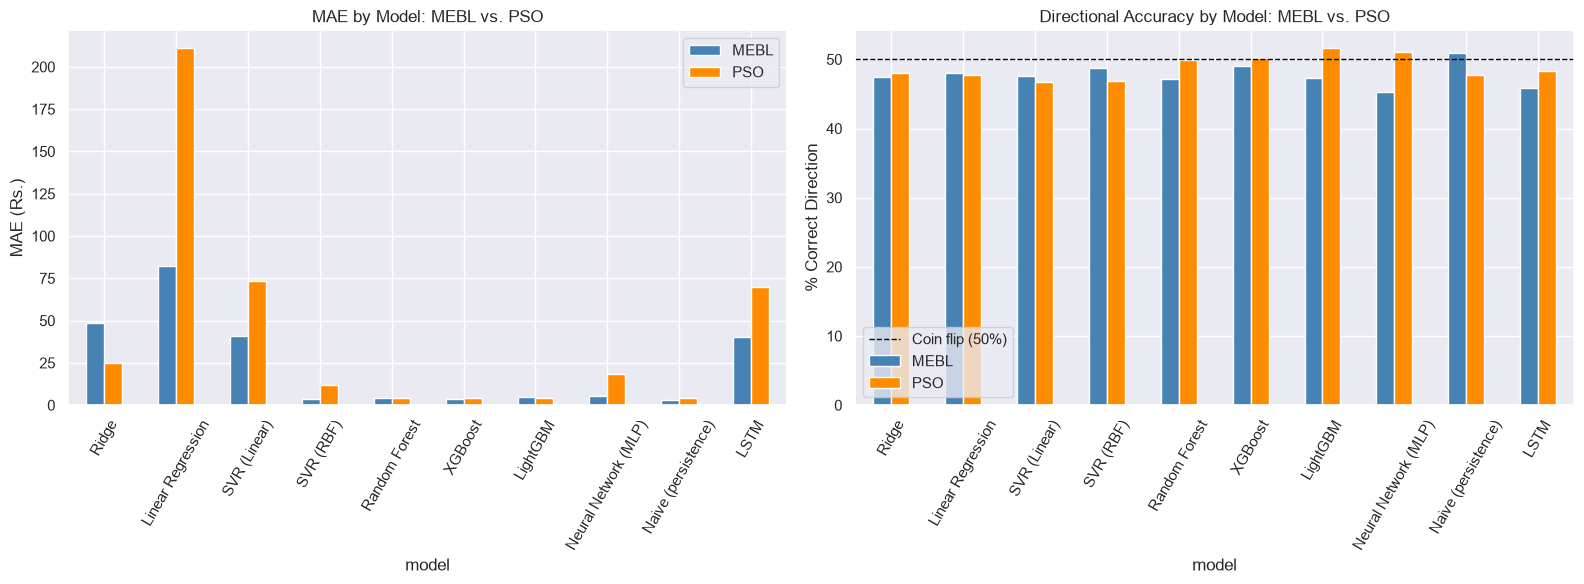

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparison_mae = pd.DataFrame({
    'MEBL': results_df['mae'],
    OTHER_TICKER: results_df_o['mae'],
})
comparison_mae.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('MAE by Model: MEBL vs. ' + OTHER_TICKER)
axes[0].set_ylabel('MAE (Rs.)')
axes[0].tick_params(axis='x', rotation=60)

comparison_dir = pd.DataFrame({
    'MEBL': results_df['directional_accuracy'],
    OTHER_TICKER: results_df_o['directional_accuracy'],
})
comparison_dir.plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].axhline(50, color='black', linestyle='--', linewidth=1, label='Coin flip (50%)')
axes[1].set_title('Directional Accuracy by Model: MEBL vs. ' + OTHER_TICKER)
axes[1].set_ylabel('% Correct Direction')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend()

plt.tight_layout()
plt.show()


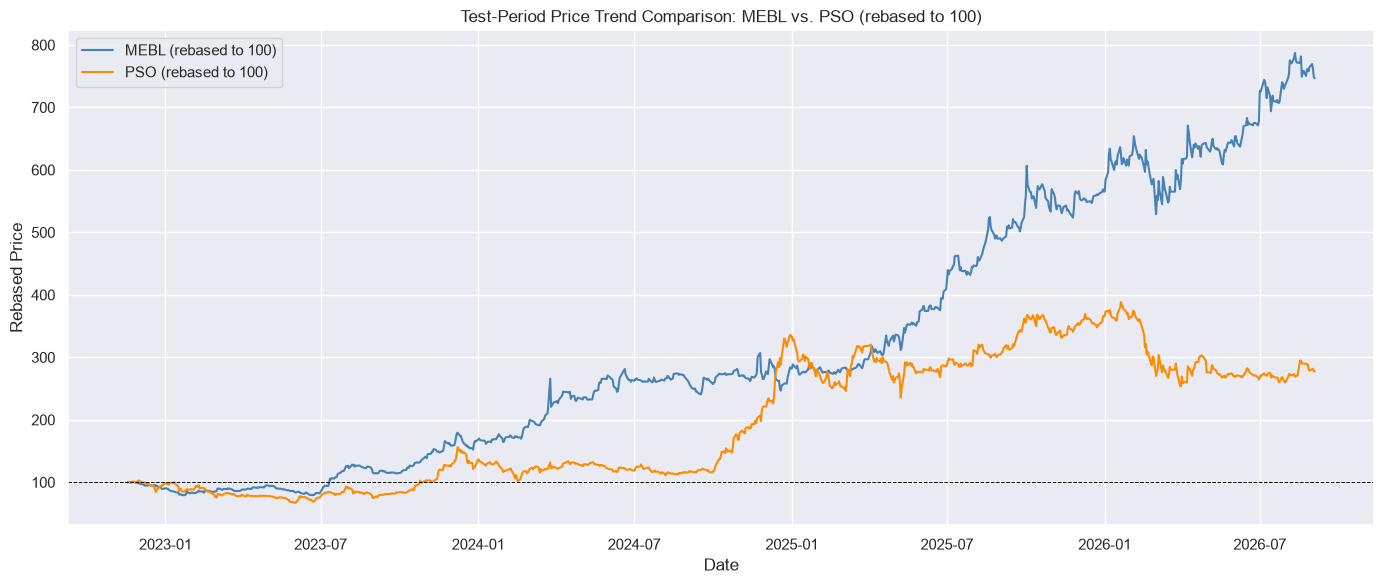

In [35]:
# Normalize both price series to 100 at the start of the shared test window so two very
# different price levels (this dataset has both a Rs. ~100 name and a Rs. ~2000+ name)
# are visually comparable on one axis.
fig, ax = plt.subplots(figsize=(14, 6))

norm_main = close_test.values / close_test.values[0] * 100
norm_other = close_test_o.values / close_test_o.values[0] * 100

ax.plot(dates_test, norm_main, label=f'{TICKER} (rebased to 100)', color='steelblue')
ax.plot(dates_test_o, norm_other, label=f'{OTHER_TICKER} (rebased to 100)', color='darkorange')
ax.axhline(100, color='black', linestyle='--', linewidth=0.7)
ax.set_title(f'Test-Period Price Trend Comparison: {TICKER} vs. {OTHER_TICKER} (rebased to 100)')
ax.set_ylabel('Rebased Price')
ax.set_xlabel('Date')
ax.legend()

plt.tight_layout()
plt.show()


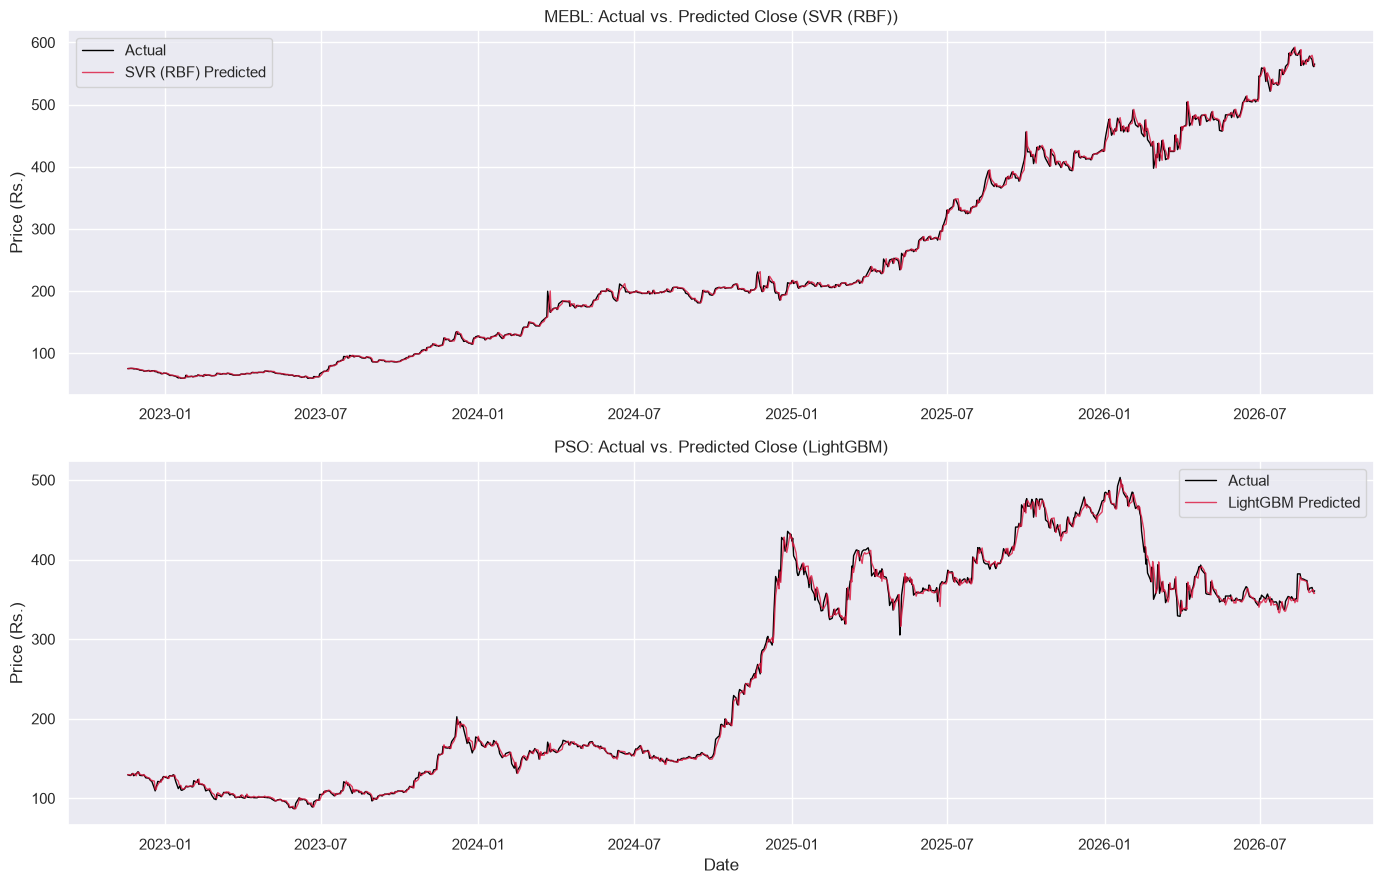

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

_pool_o = results_df_o.drop(index=['Naive (persistence)', 'LSTM'], errors='ignore')
best_name_o = _pool_o['mae'].idxmin()
best_preds_o = predictions_o[best_name_o]
pred_prices_o = close_test_o.values * (1 + best_preds_o)
actual_prices_o = close_test_o.values * (1 + y_test_o.values)

axes[0].plot(dates_test, actual_prices, label='Actual', color='black', linewidth=1)
axes[0].plot(dates_test, pred_prices, label=f'{best_model_name} Predicted', color='crimson', linewidth=1, alpha=0.8)
axes[0].set_title(f'{TICKER}: Actual vs. Predicted Close ({best_model_name})')
axes[0].set_ylabel('Price (Rs.)')
axes[0].legend()

axes[1].plot(dates_test_o, actual_prices_o, label='Actual', color='black', linewidth=1)
axes[1].plot(dates_test_o, pred_prices_o, label=f'{best_name_o} Predicted', color='crimson', linewidth=1, alpha=0.8)
axes[1].set_title(f'{OTHER_TICKER}: Actual vs. Predicted Close ({best_name_o})')
axes[1].set_ylabel('Price (Rs.)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()


## 19. Conclusion

Run this notebook top-to-bottom to populate the summary below with real numbers for both
tickers (`results_df` / `results_df_o`), across all ~9 models (linear, kernel/SVM, tree
ensemble, and two deep learning architectures). Key things to look for:

- Does **any** model beat the naive persistence baseline on directional accuracy by a
  meaningful margin (not just a fraction of a percentage point)? Given next-day return is
  close to a random walk, a small, consistent edge over 50% is a realistic bar - not near-100%.
- Do the tree ensembles' or deep learning models' price-error metrics (MAE/RMSE) beat the
  naive baseline? They often win here even when directional accuracy is closer to a coin
  flip, because they're better at not overshooting on quiet days.
- Does the family-level view (Section 12) show tree ensembles and deep learning
  systematically outperforming linear/kernel methods on this feature set, or is the gap
  mostly noise at this sample size? With ~4,850 rows and 270+ features, a wide accuracy
  gap between families is a genuine finding; a narrow one is a reason to collect more
  data/features before trusting any single model's ranking.
- Compare the two tickers' results directly: a sector or liquidity difference between them
  (see each notebook's Section 1 sector printout) may explain why one ticker's next-day
  return is more/less predictable than the other's.
- Check Section 13/18.1's overfitting diagnosis for every model, not just the "best" one by
  test MAE - a model with the lowest test error but a large train/test gap is less
  trustworthy going forward than one with a smaller gap and a slightly higher test error,
  since the gap is a direct measure of how much of its test performance is likely luck
  specific to this particular test window versus a pattern that should hold up out of
  sample.
- Section 14 concretely tested the fix for both failure modes: did hyperparameter tuning
  close the tree ensembles' overfitting gap without hurting test performance, and did it
  reveal that the "underfitting" models (Ridge/SVR/MLP) were actually just badly regularized
  - or confirm that they need a different fix entirely (more/better features, a different
  problem framing) rather than a hyperparameter search? Compare `tuning_summary_df` and
  `tuned_diag_df` against Section 13's untuned `diag_df` for the real answer on this ticker.